# Connect Forest Management Model with Forest Carbon Budget Model

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [2]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [3]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons',  'bau_redchrs', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'bau_gldbr', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'bau_eqtslvr', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='goldenbear',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='min_em',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', index=1, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'bau_redchrs', 'redchrs_AAC_90…

Dropdown(description='Objective:', index=3, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='min_em')

In [4]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [5]:
#Start Calculating the Running Time
Start = time.time()

In [6]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [7]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [8]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [9]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [10]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/goldenbear_c_curves_p.pkl
Loaded data from ./inputs/curves/goldenbear_c_curves_f.pkl


In [11]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

Running for goldenbear_min_em_no_cons...
running no_cons scenario
Set parameter Username
Academic license - for non-commercial use only - expires 2025-01-09
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3905 rows, 36130 columns and 36130 nonzeros
Model fingerprint: 0x4f5a416c
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 3905 rows and 36130 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -6.0559363e+06   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.01 work units)
Optimal objective -6.055936349e+06


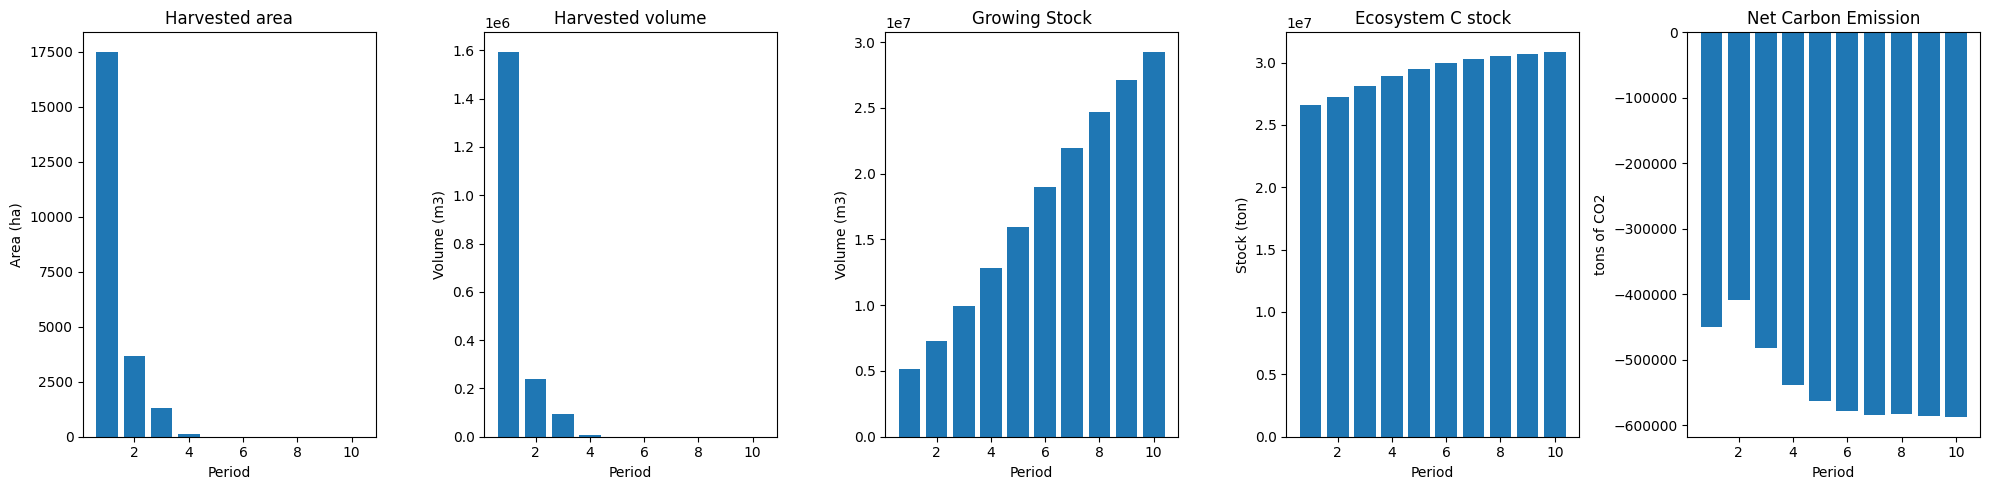

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_no_cons_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  2042
The economic indicator (the provincial government revenues) is:  69651
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


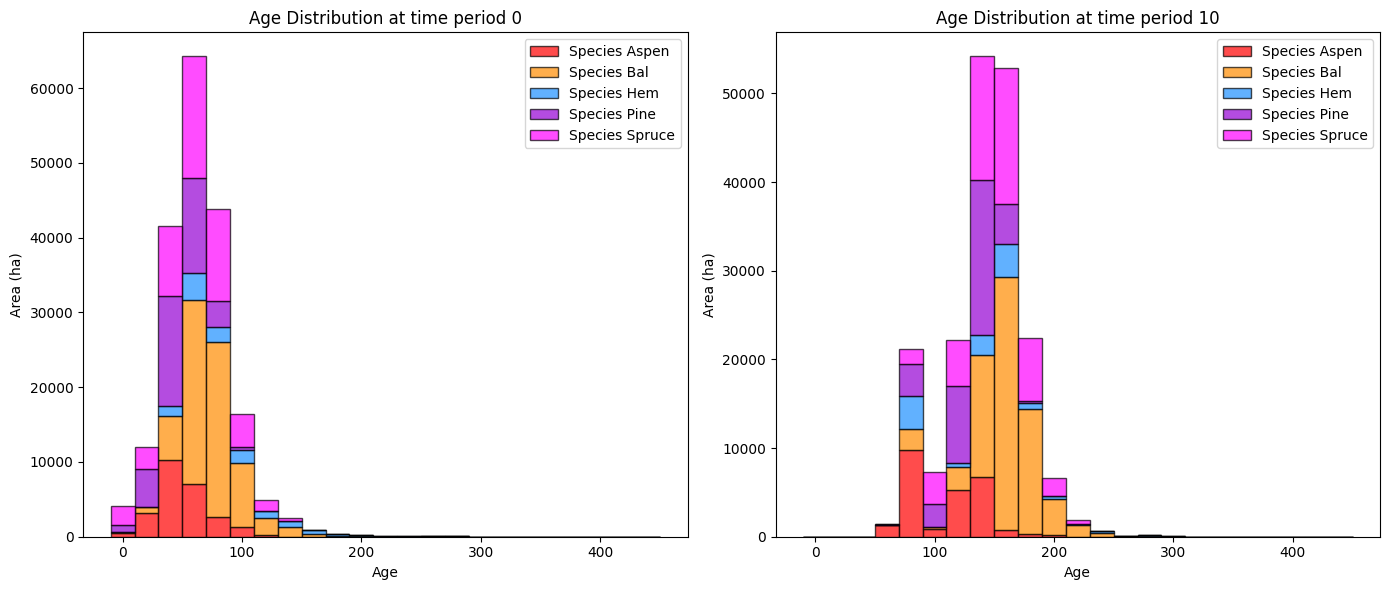

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_no_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   6919.787037   6917.078503
Bal     278.565372  13884.040142  13605.474770
Aspen   273.490478   4454.493720   4181.003242
Pine      0.000000   5508.131174   5508.131174
Hem     419.699331   1123.847880    704.148549

Overall diversity has **increased** by 30915.84 hectares from time period 0 to time period 10.


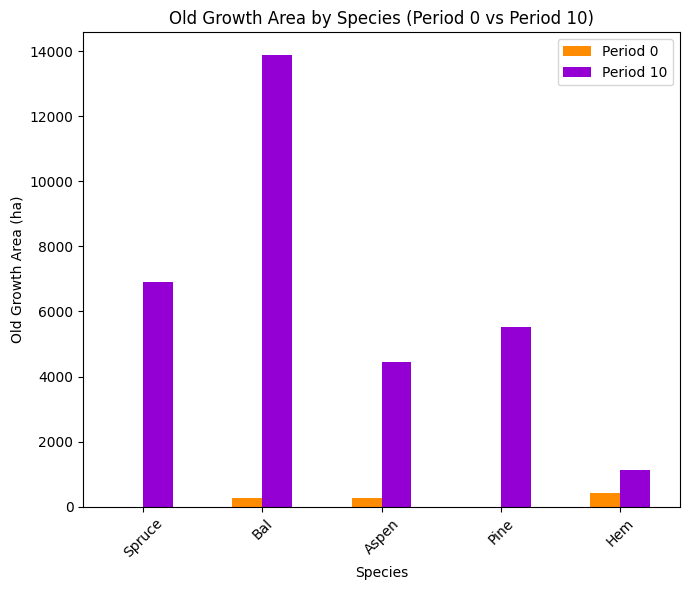

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_no_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9083

Diversity has **decreased** by 3.72% from time 0 to time 10.


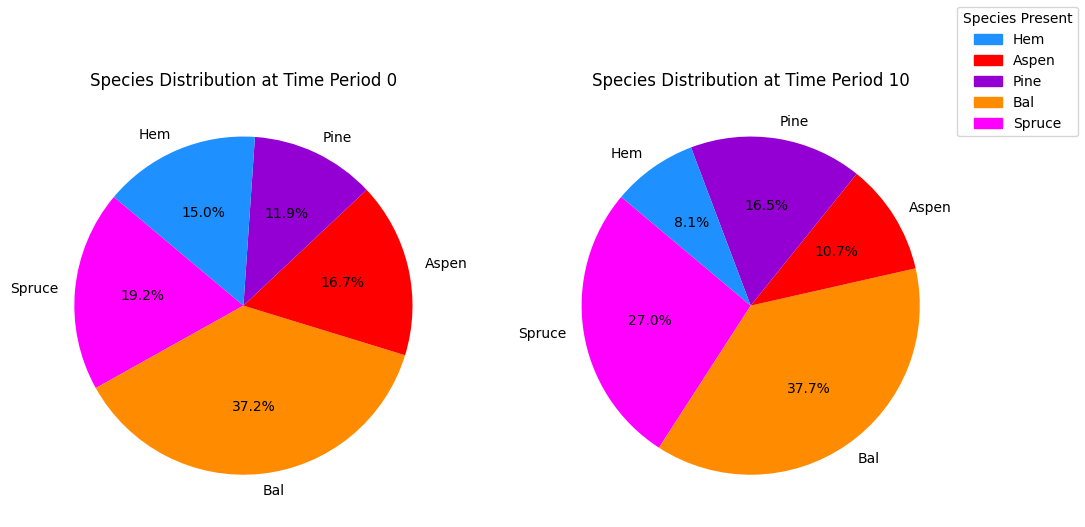

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_no_cons_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x1b9e9885
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 4e+07]
Presolve removed 2037 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1912 rows, 34099 columns, 421112 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 6.876e+04
 Factor NZ  : 9.245e+04 (roughly 15 MB of memory)
 Factor Ops

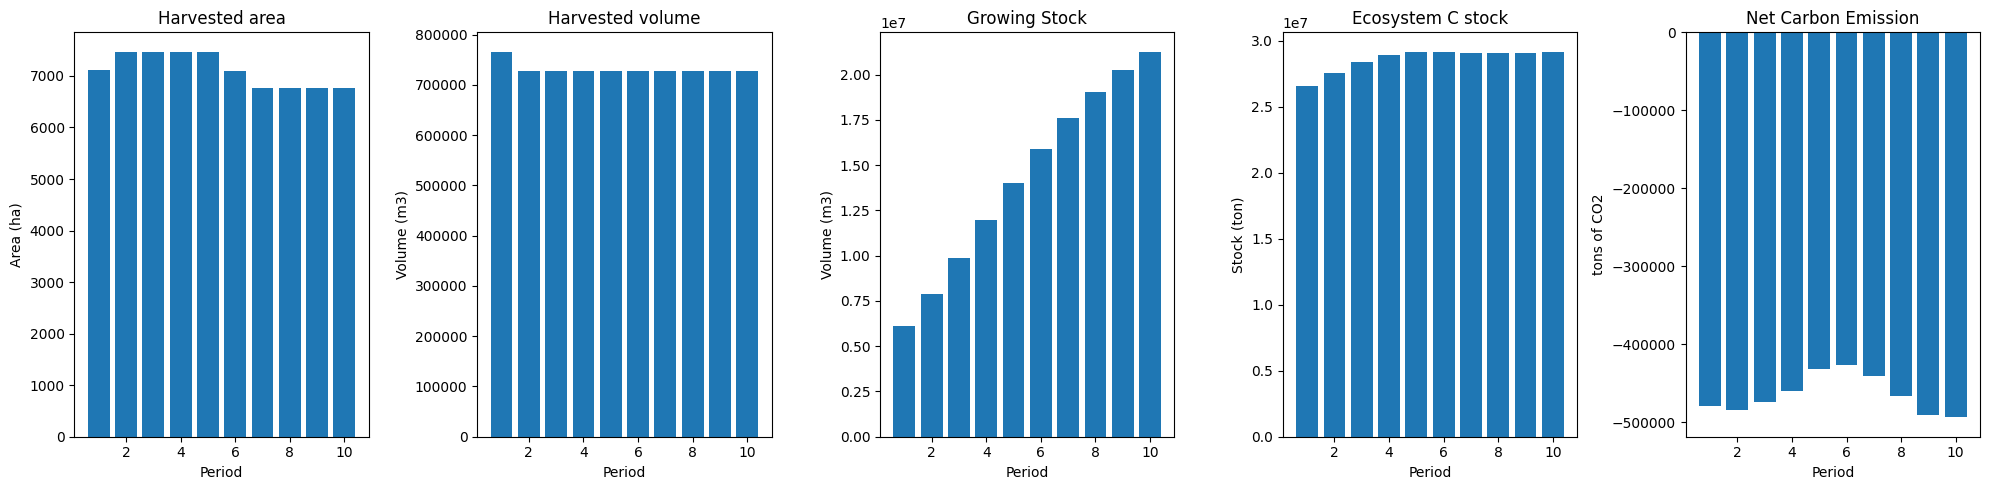

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


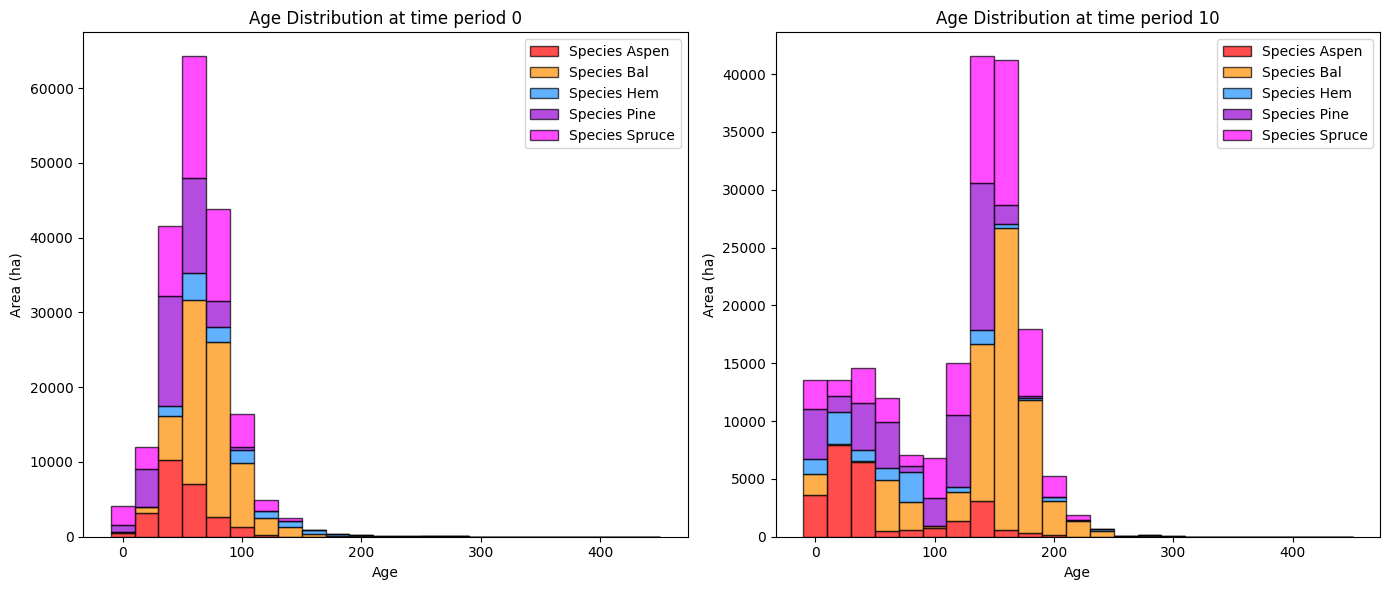

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Overall diversity has **increased** by 21663.54 hectares from time period 0 to time period 10.


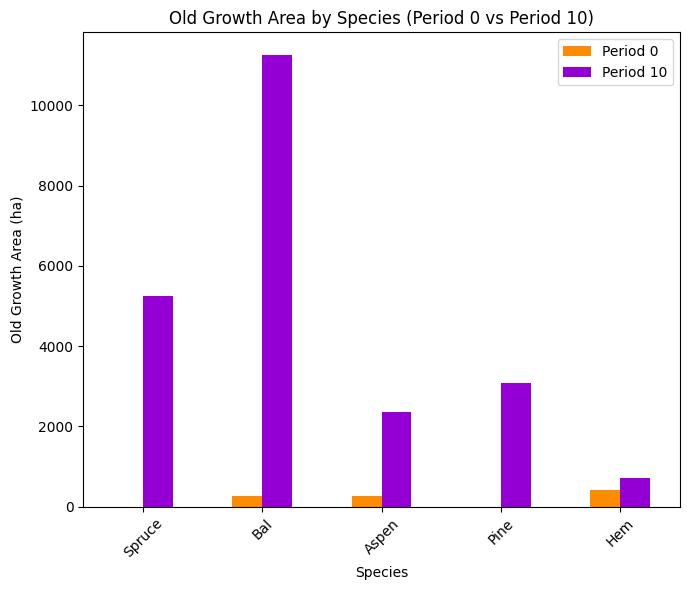

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


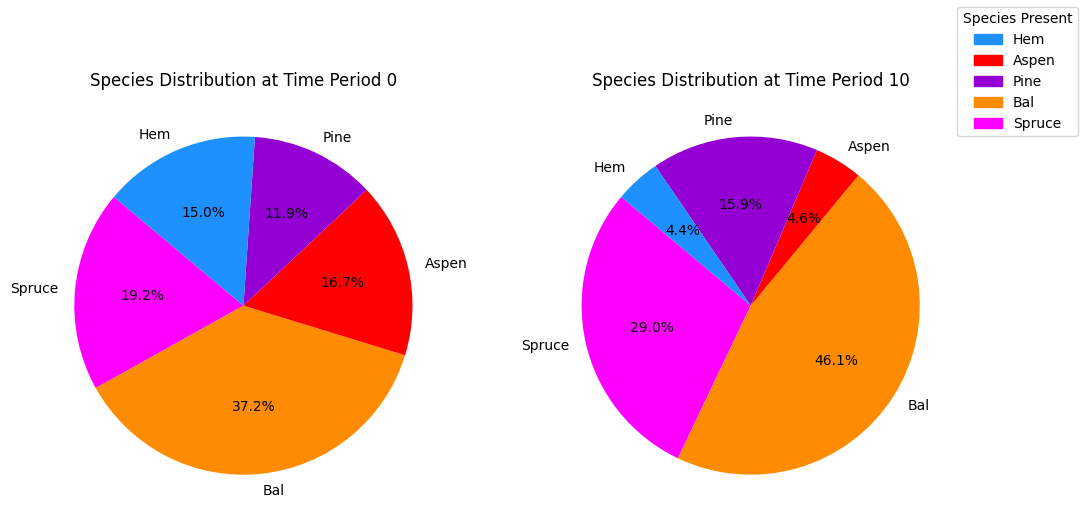

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


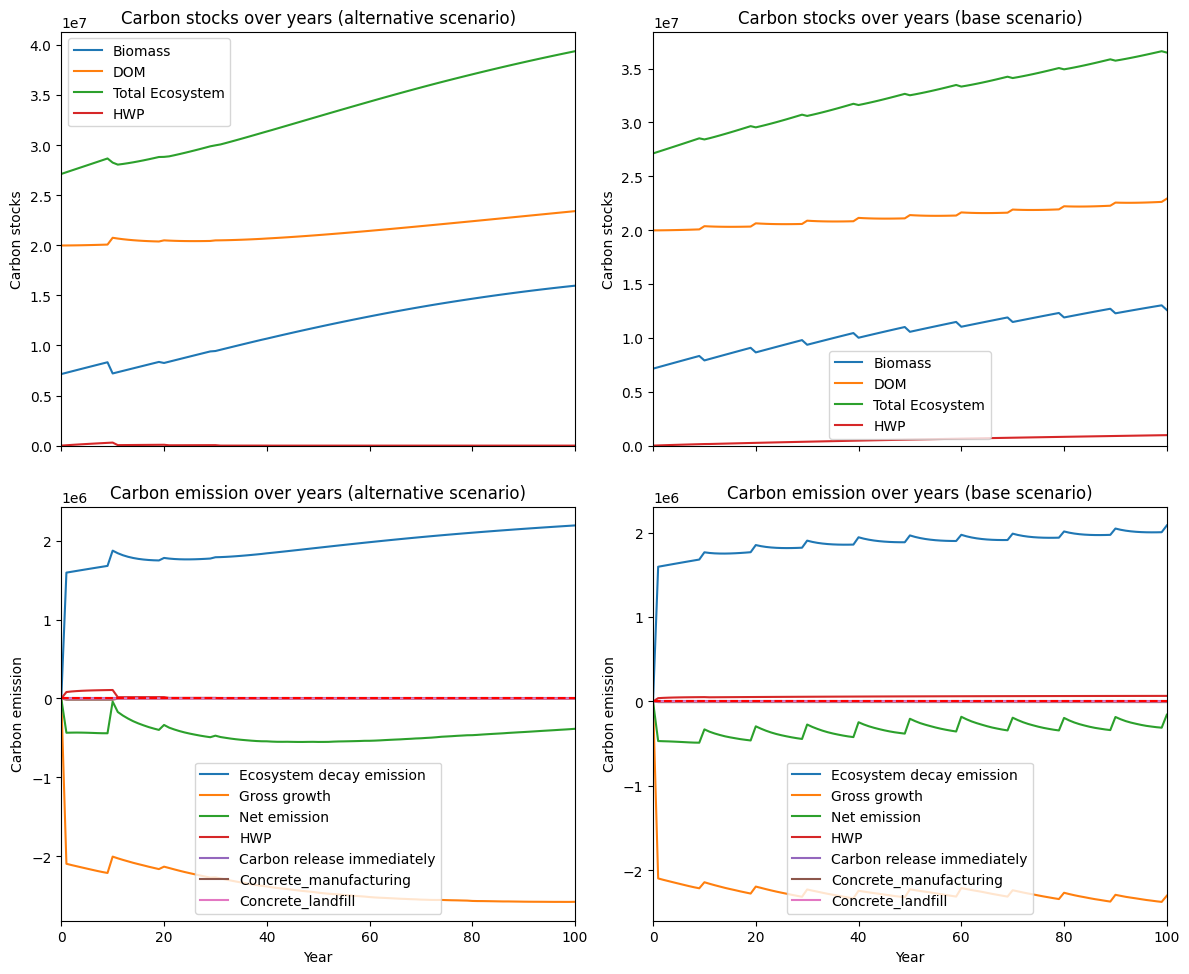

---------------------------------------------------------------------------------------
Net emission difference 1484957.0420171283
Net emission base scenario -8638904.272013629
Net emission alternative scenario -10123861.314030755
dollar_per_ton is:  6.73420154054844
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  1676.977322  1676.977322
Bal     0.0  2631.045777  2631.045777
Aspen   0.0  2104.526145  2104.526145
Pine    0.0  2420.934814  2420.934814
Hem     0.0   418.807484   418.807484

Overall, the old growth area has **increased** by 9252.29 hectares in the alternative scenario compared to the base scenario.


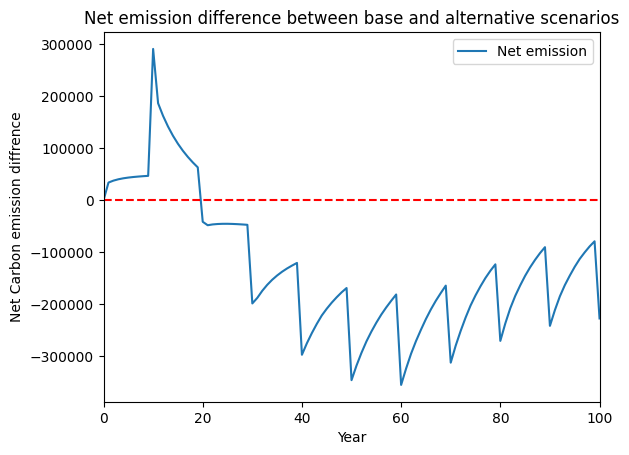

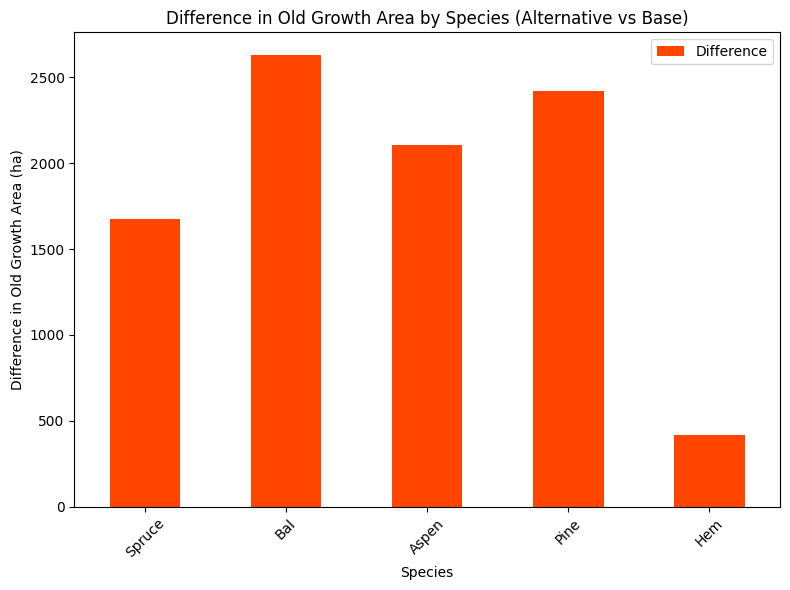

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


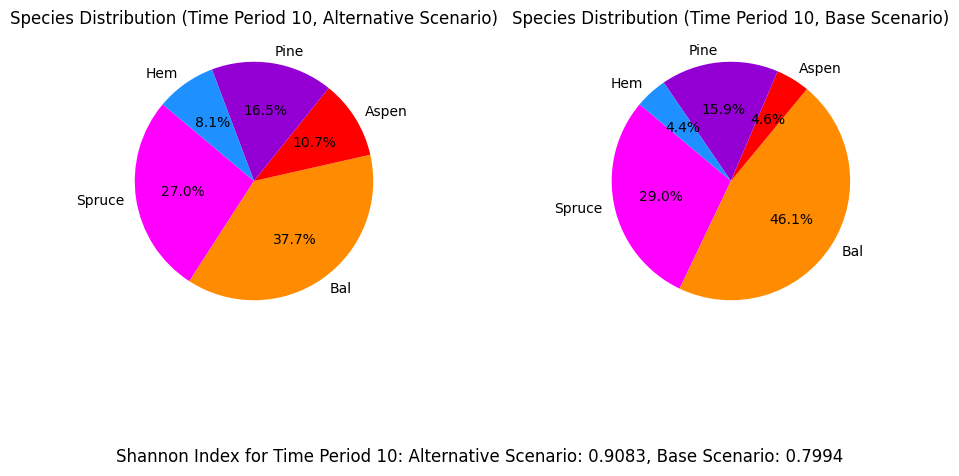

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_evenflow_cons...
running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3945 rows, 36130 columns and 430076 nonzeros
Model fingerprint: 0x49dedfba
Coefficient statistics:
  Matrix range     [1e-02, 9e+04]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 2035 rows and 2031 columns
Presolve time: 0.10s
Presolved: 1910 rows, 34099 columns, 402875 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering ti

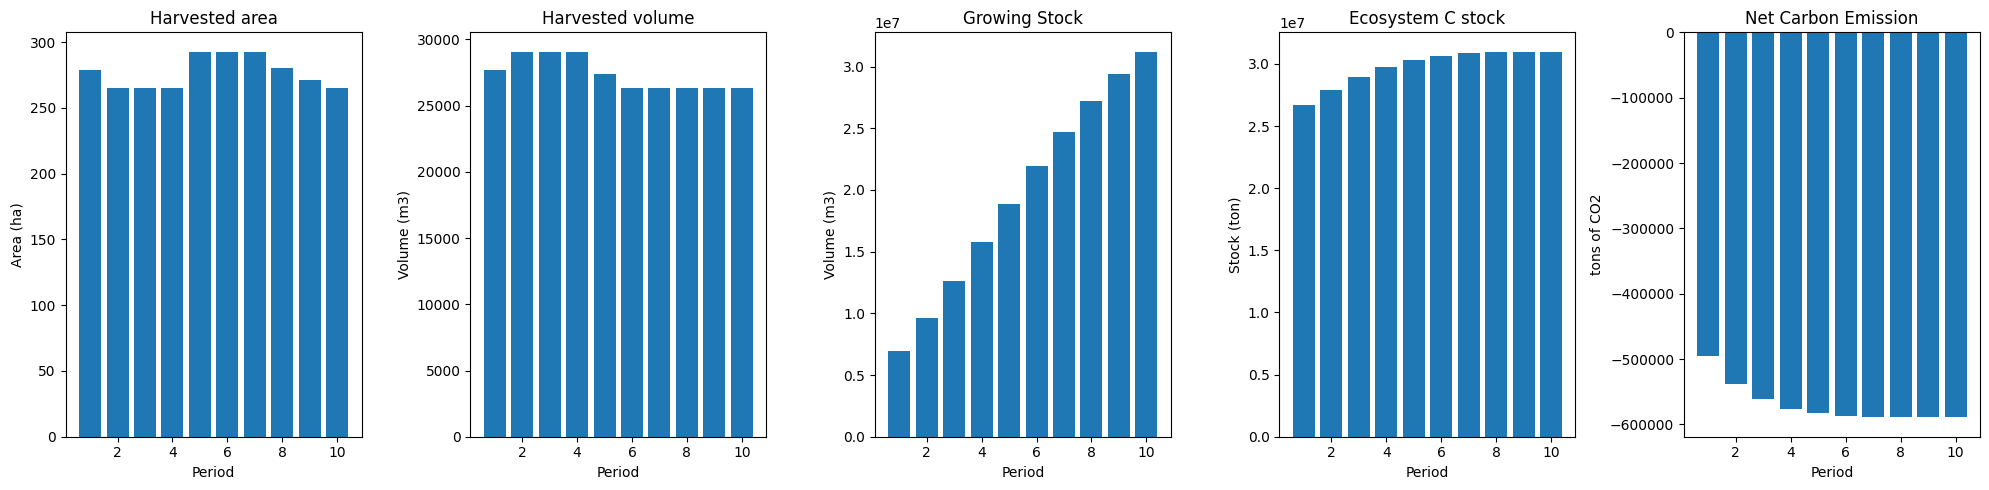

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_evenflow_cons_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  289
The economic indicator (the provincial government revenues) is:  9876
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


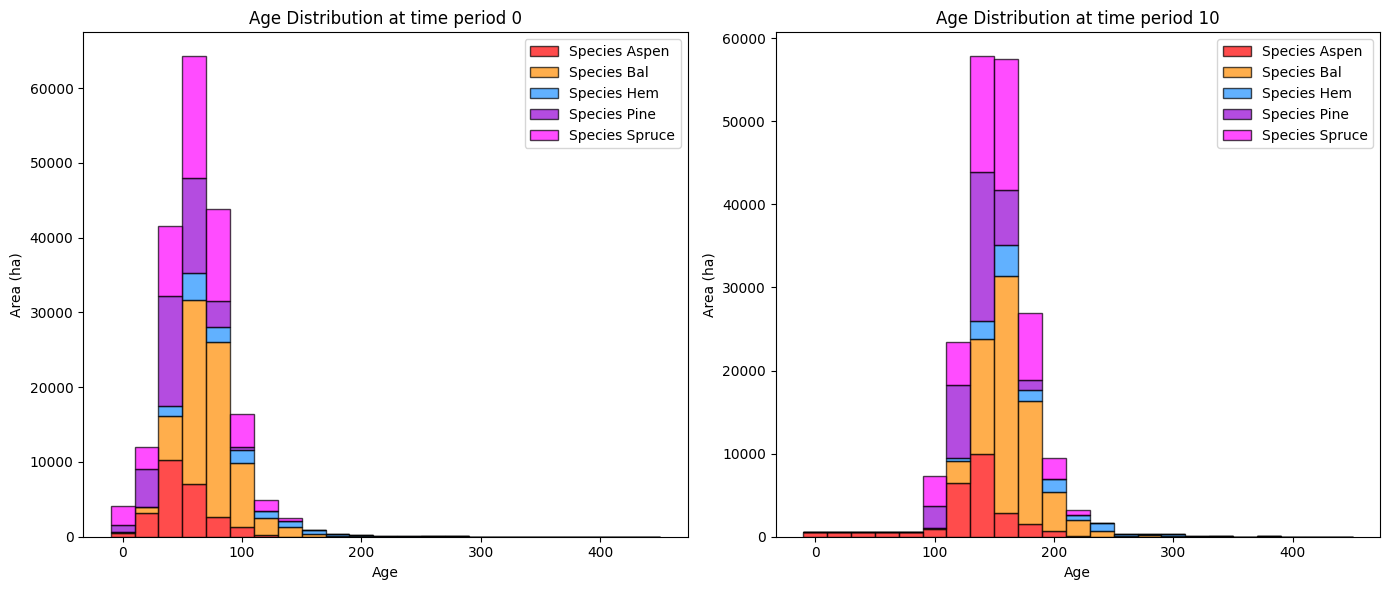

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   8040.264040   8037.555506
Bal     278.565372  15963.007735  15684.442363
Aspen   273.490478  11184.542230  10911.051752
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   3929.593538   3509.894208

Overall diversity has **increased** by 45774.83 hectares from time period 0 to time period 10.


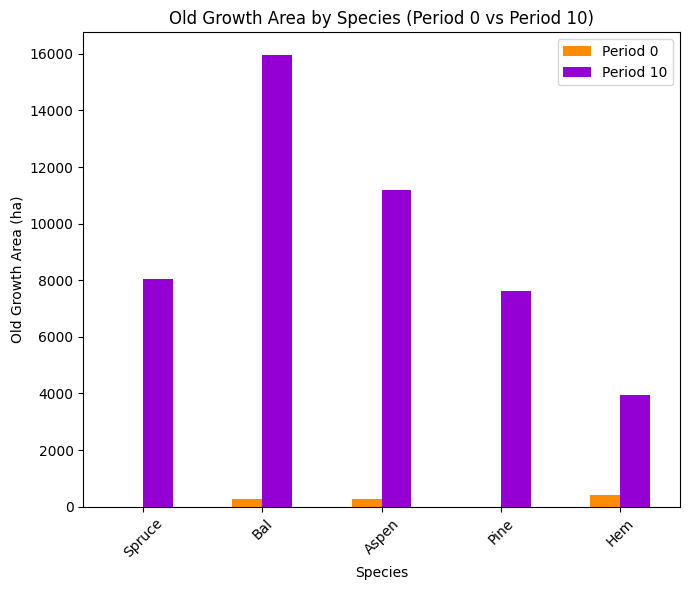

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9254

Diversity has **decreased** by 2.02% from time 0 to time 10.


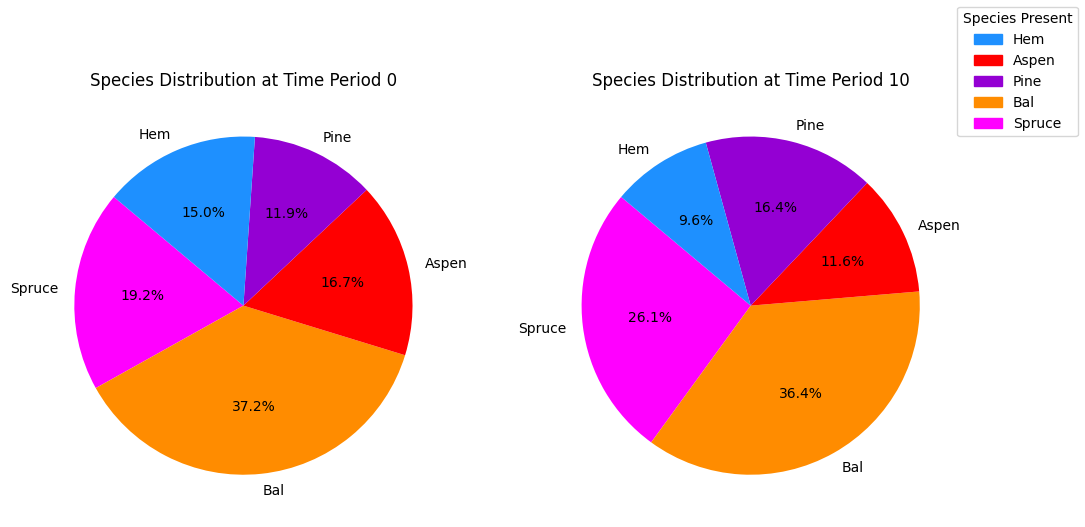

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_evenflow_cons_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x1b9e9885
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 4e+07]
Presolve removed 2037 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1912 rows, 34099 columns, 421112 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 6.876e+04
 Factor NZ  : 9.245e+04 (roughly 15 MB of memory)
 Fact

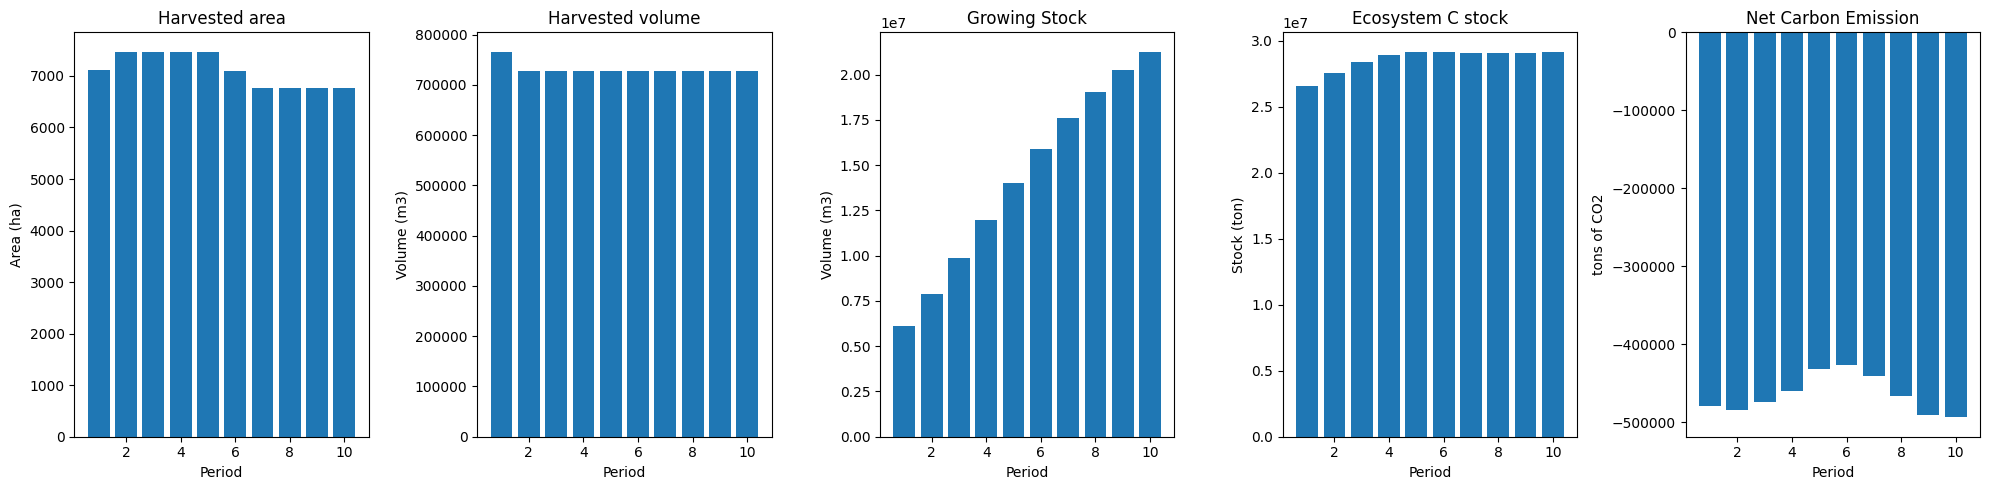

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


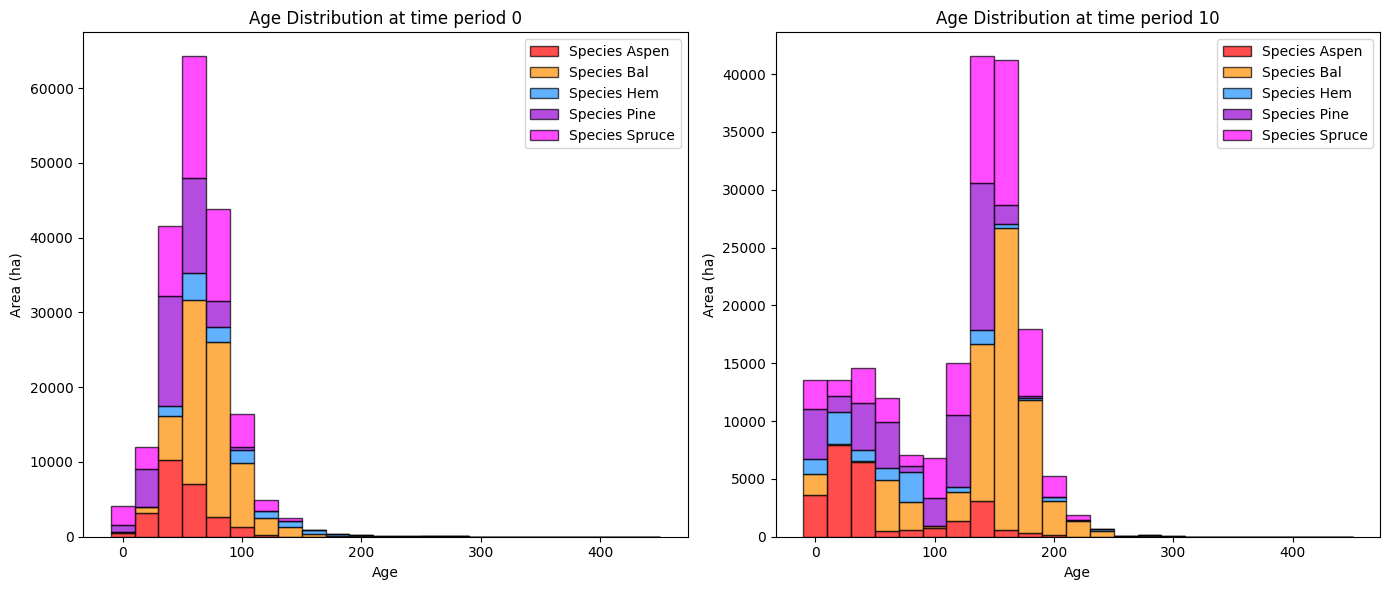

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Overall diversity has **increased** by 21663.54 hectares from time period 0 to time period 10.


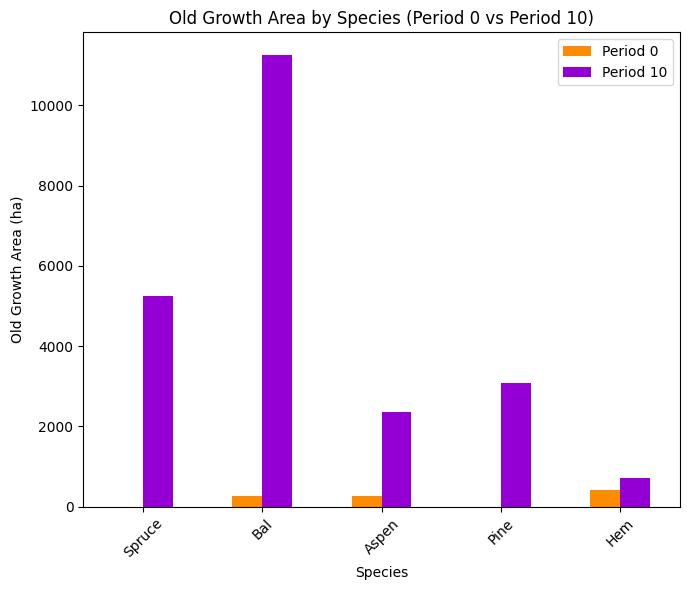

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


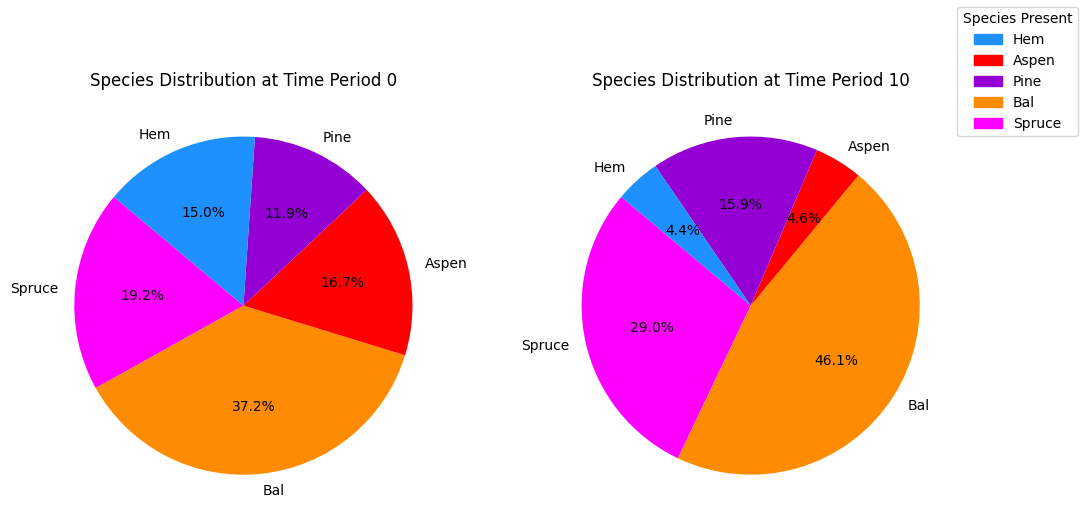

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


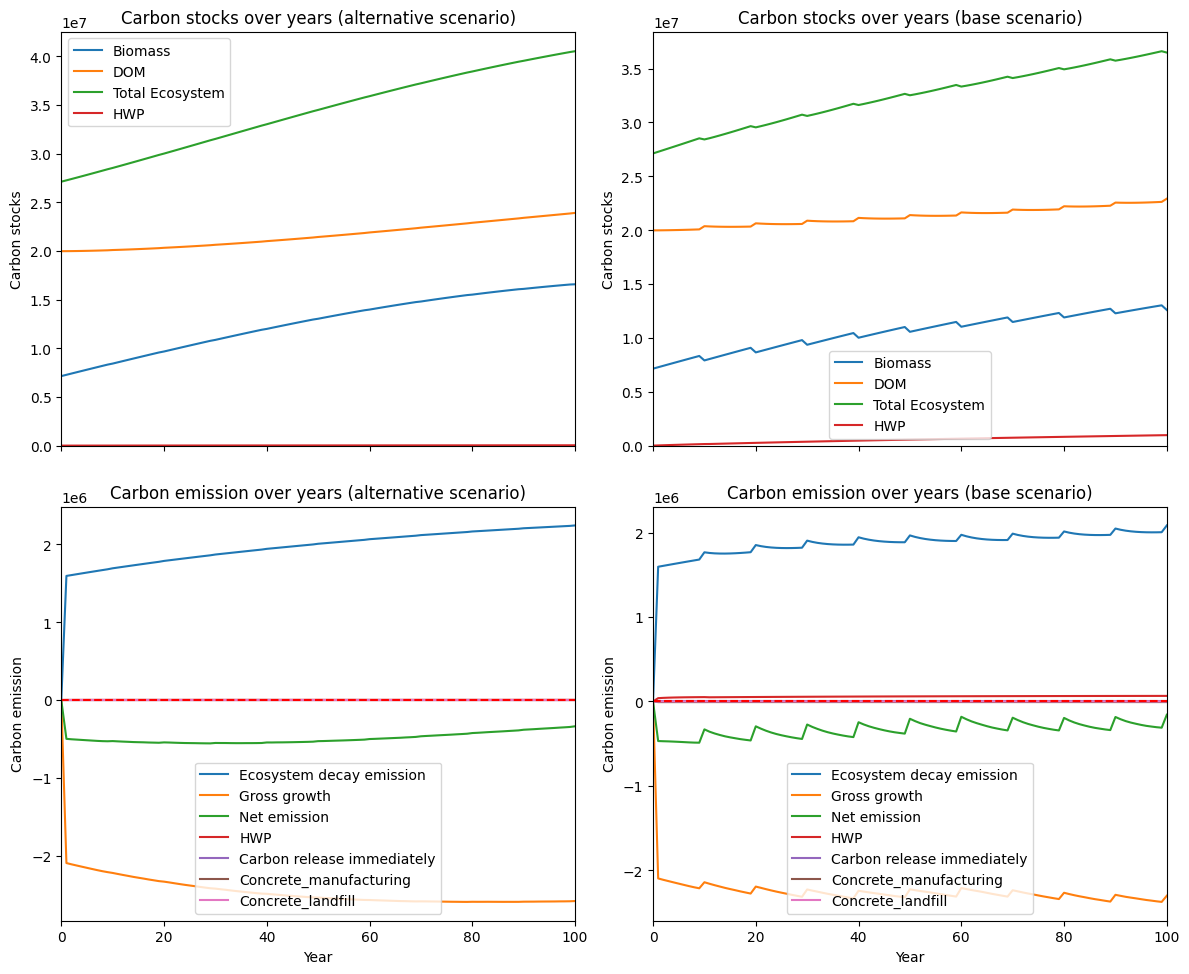

---------------------------------------------------------------------------------------
Net emission difference -2666343.0170135503
Net emission base scenario -12790204.331044307
Net emission alternative scenario -10123861.314030755
dollar_per_ton is:  3.750455187570182
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2797.454325  2797.454325
Bal     0.0  4710.013370  4710.013370
Aspen   0.0  8834.574655  8834.574655
Pine    0.0  4544.690840  4544.690840
Hem     0.0  3224.553142  3224.553142

Overall, the old growth area has **increased** by 24111.29 hectares in the alternative scenario compared to the base scenario.


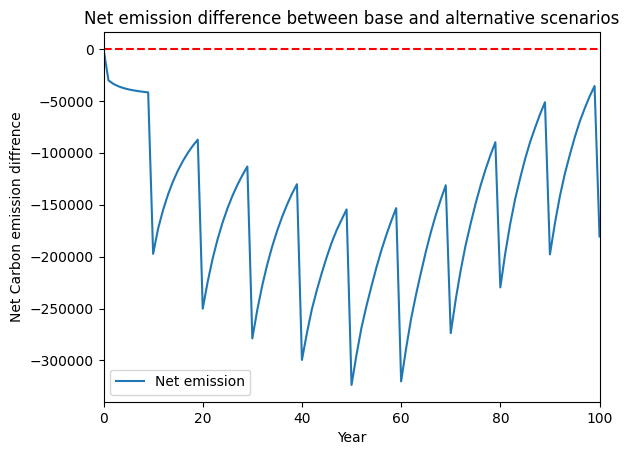

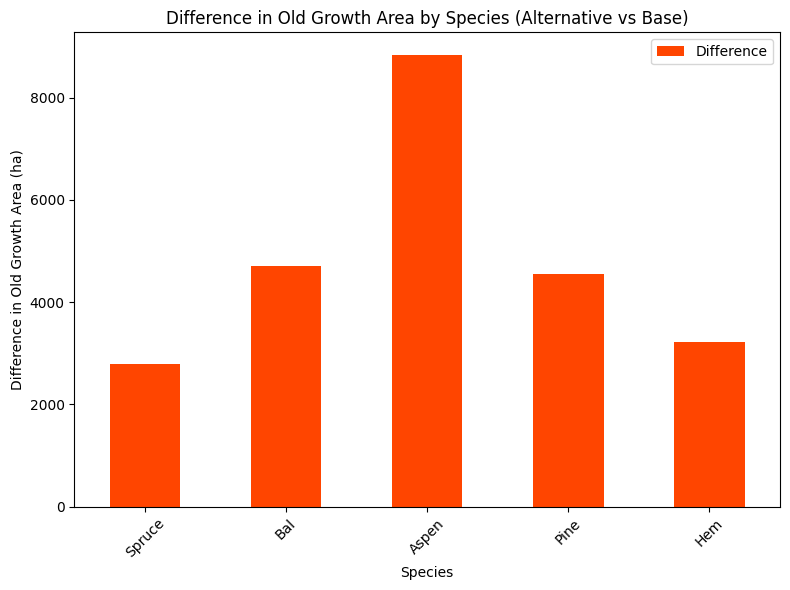

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


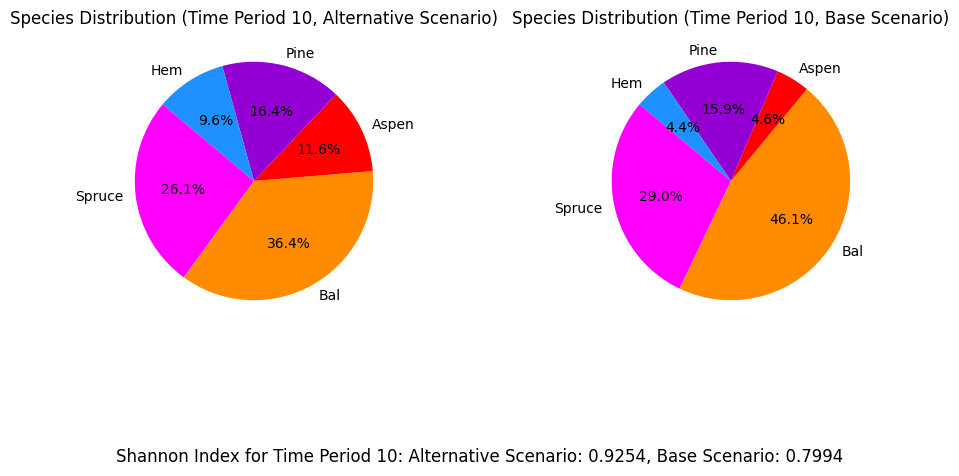

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_bau_gldbr...
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x1b9e9885
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 4e+07]
Presolve removed 2037 rows and 2031 columns
Presolve time: 0.18s
Presolved: 1912 rows, 34099 columns, 421112 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier lo

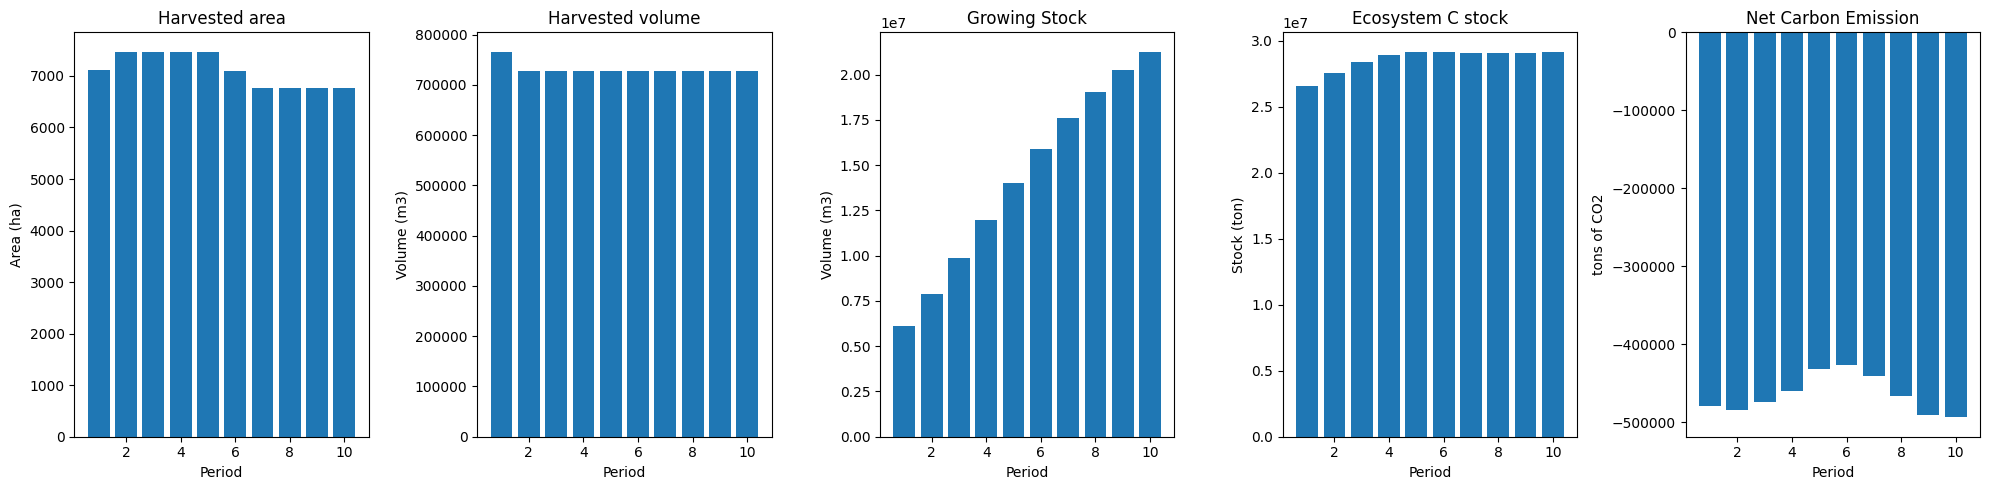

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


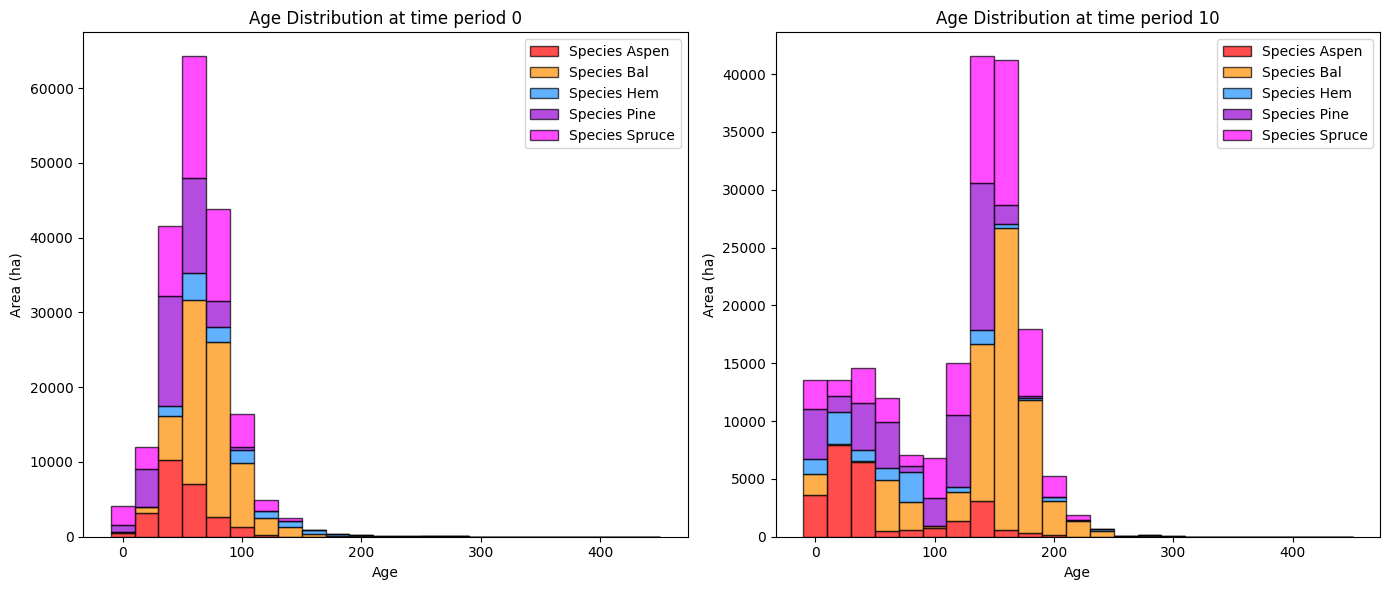

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Overall diversity has **increased** by 21663.54 hectares from time period 0 to time period 10.


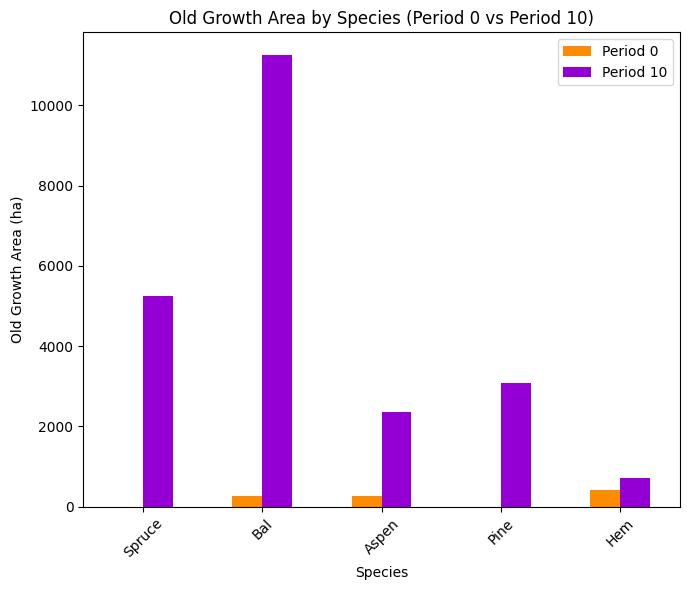

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


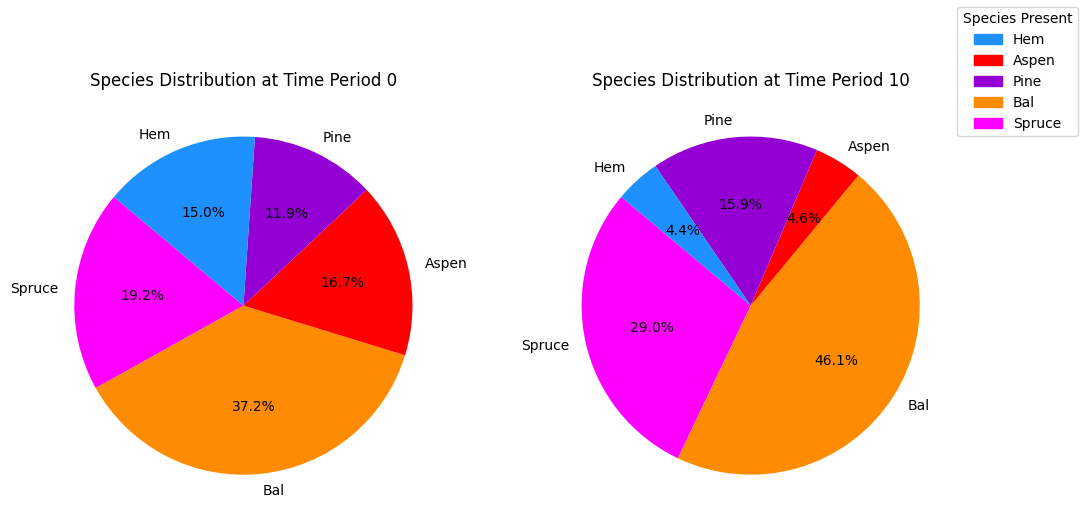

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x1b9e9885
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 4e+07]
Presolve removed 2037 rows and 2031 columns
Presolve time: 0.12s
Presolved: 1912 rows, 34099 columns, 421112 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 6.876e+04
 Factor NZ  : 9.245e+04 (roughly 15 MB of memory)
 Factor O

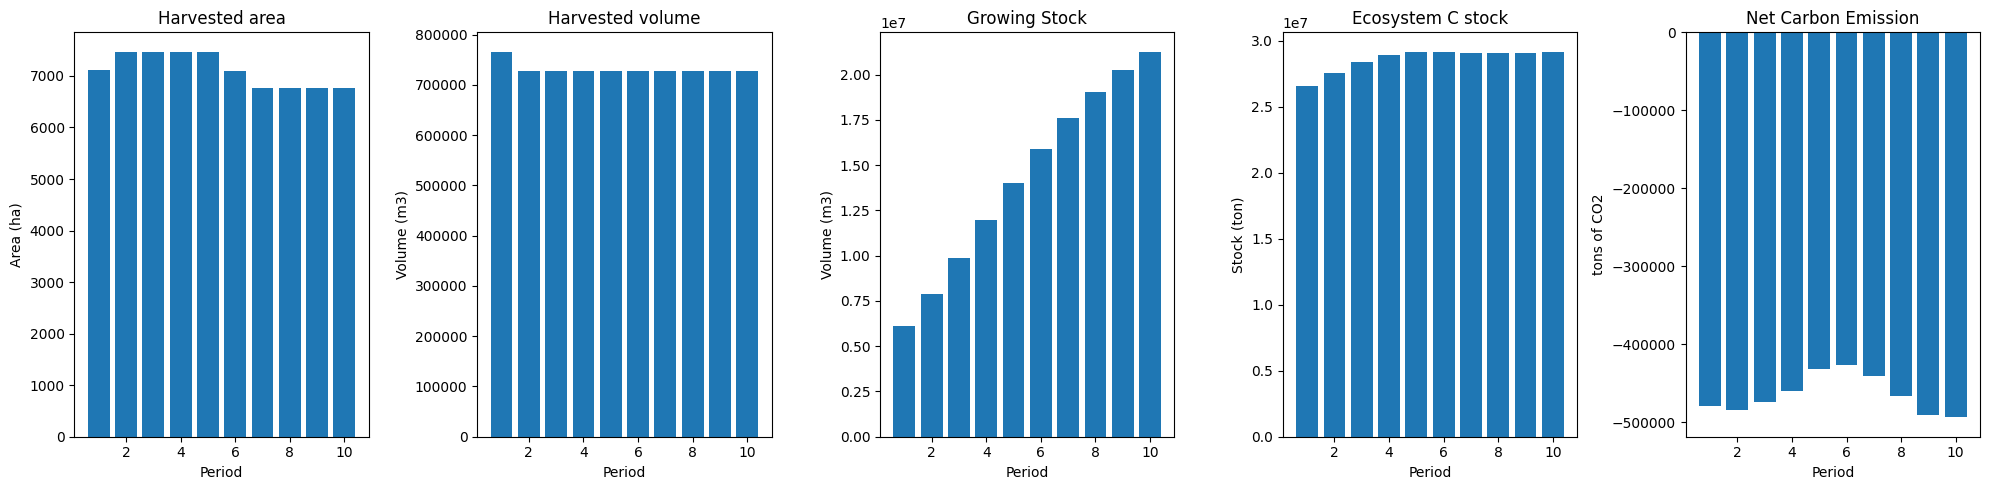

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


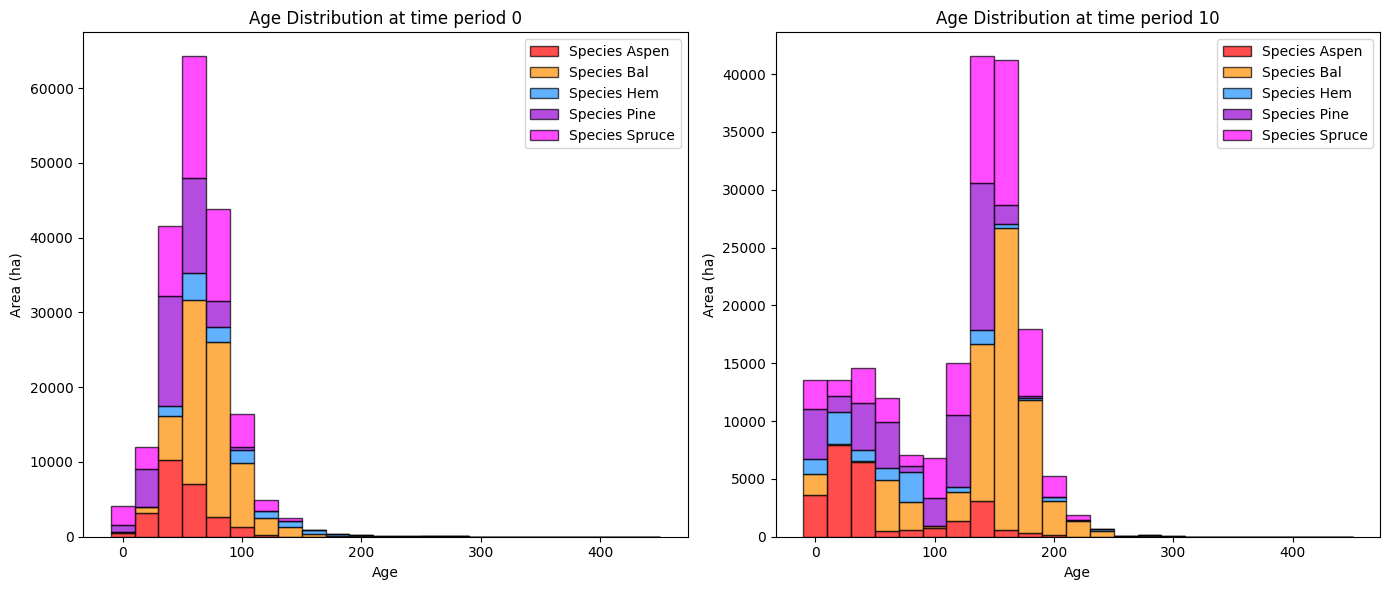

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Overall diversity has **increased** by 21663.54 hectares from time period 0 to time period 10.


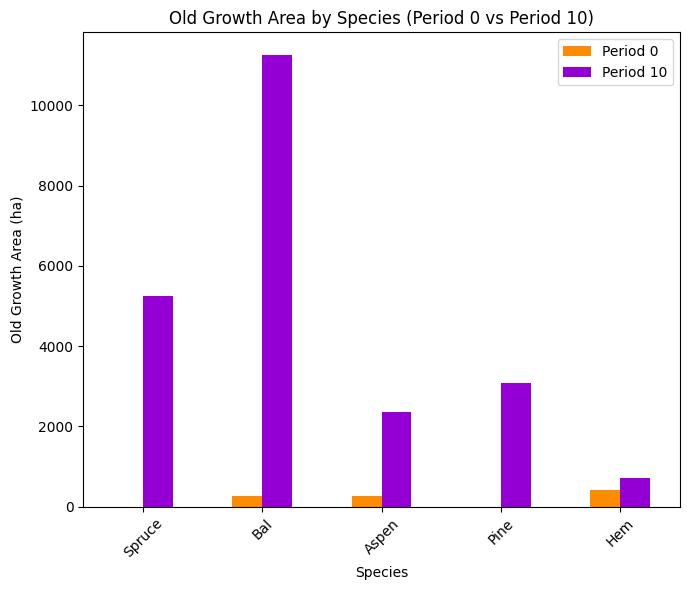

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


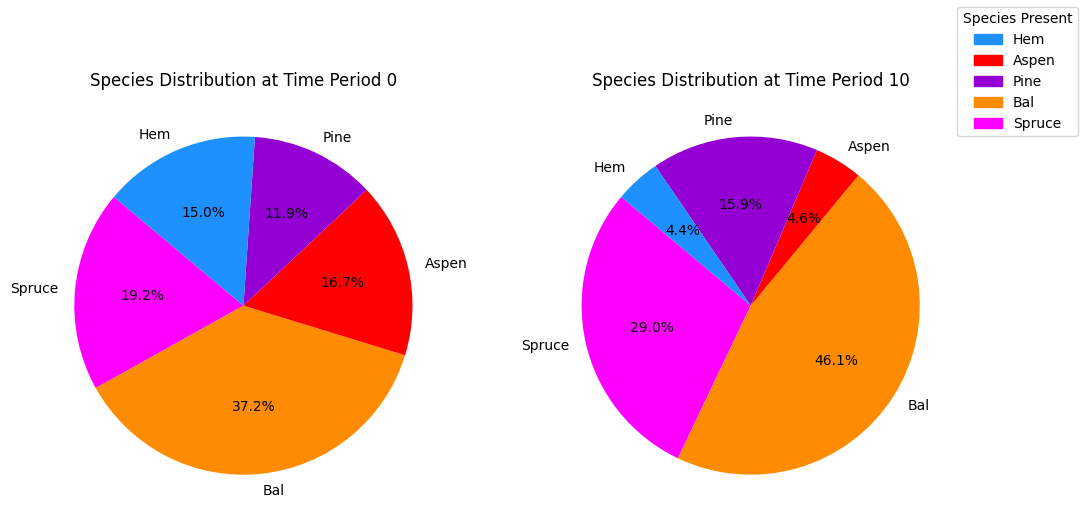

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


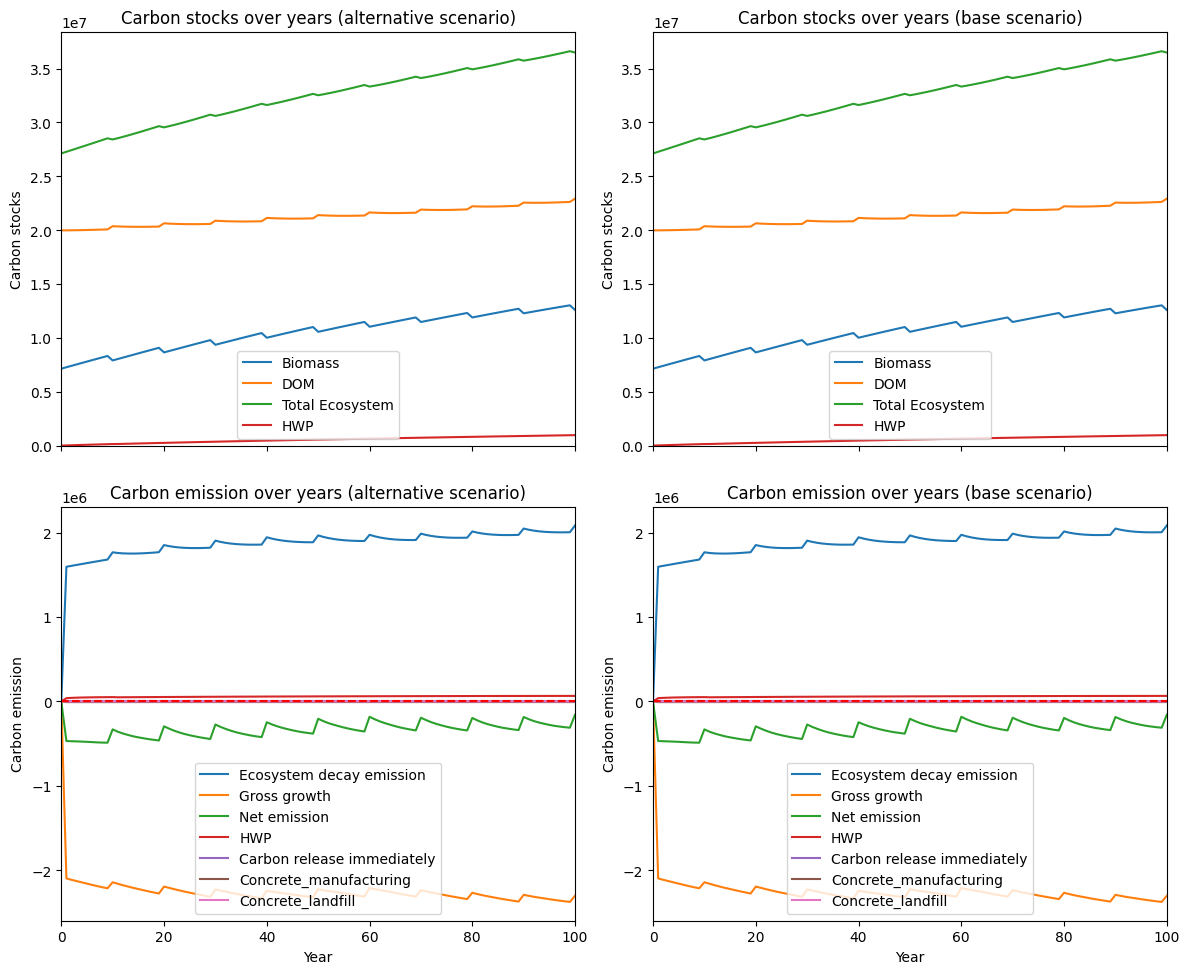

---------------------------------------------------------------------------------------
Net emission difference 0.0
Net emission base scenario -10123861.314030755
Net emission alternative scenario -10123861.314030755
dollar_per_ton is:  inf
Comparison of Old Growth Areas (Alternative - Base)
          0   10  Difference
Spruce  0.0  0.0         0.0
Bal     0.0  0.0         0.0
Aspen   0.0  0.0         0.0
Pine    0.0  0.0         0.0
Hem     0.0  0.0         0.0

Overall, the old growth area has **increased** by 0.00 hectares in the alternative scenario compared to the base scenario.


/media/data/project/eghasemi/nbds_mining/util_opt.py:1211: RuntimeWarning: divide by zero encountered in scalar divide
  dollar_per_ton = abs(budget_input / dif_scenario.iloc[:25]['Net emission'].sum())


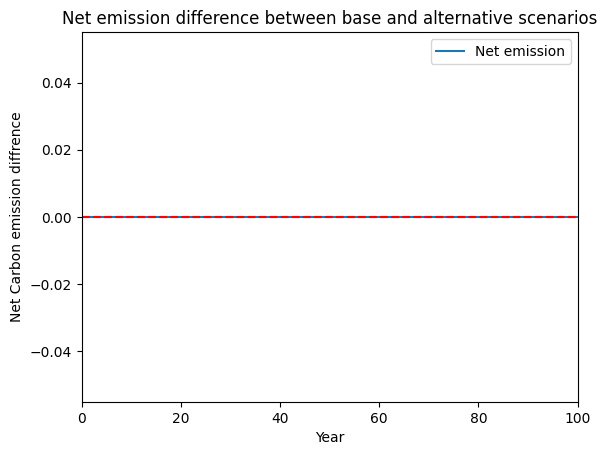

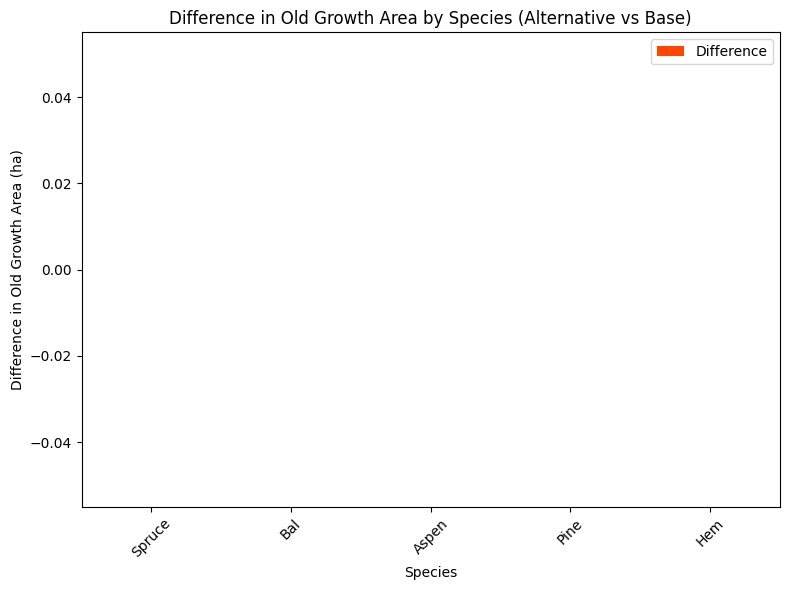

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


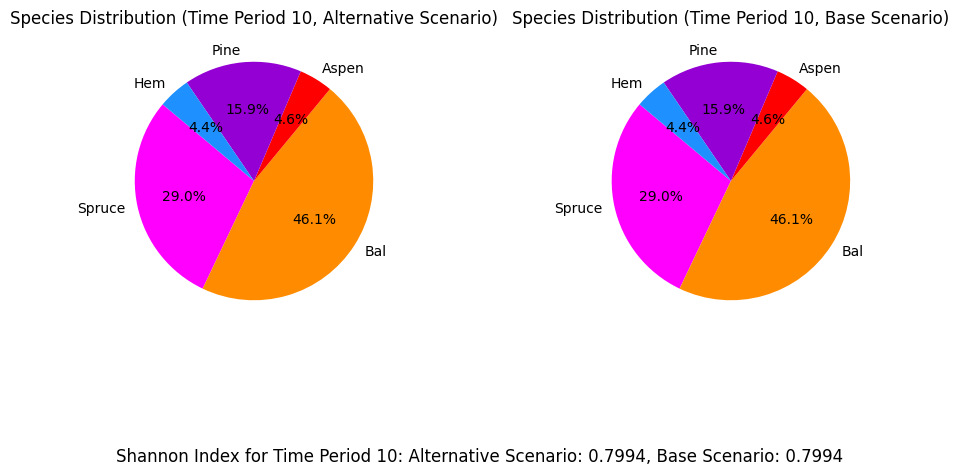

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_90%...
running the scenario for the Golden Bear mining site (90%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xf554c511
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34100 

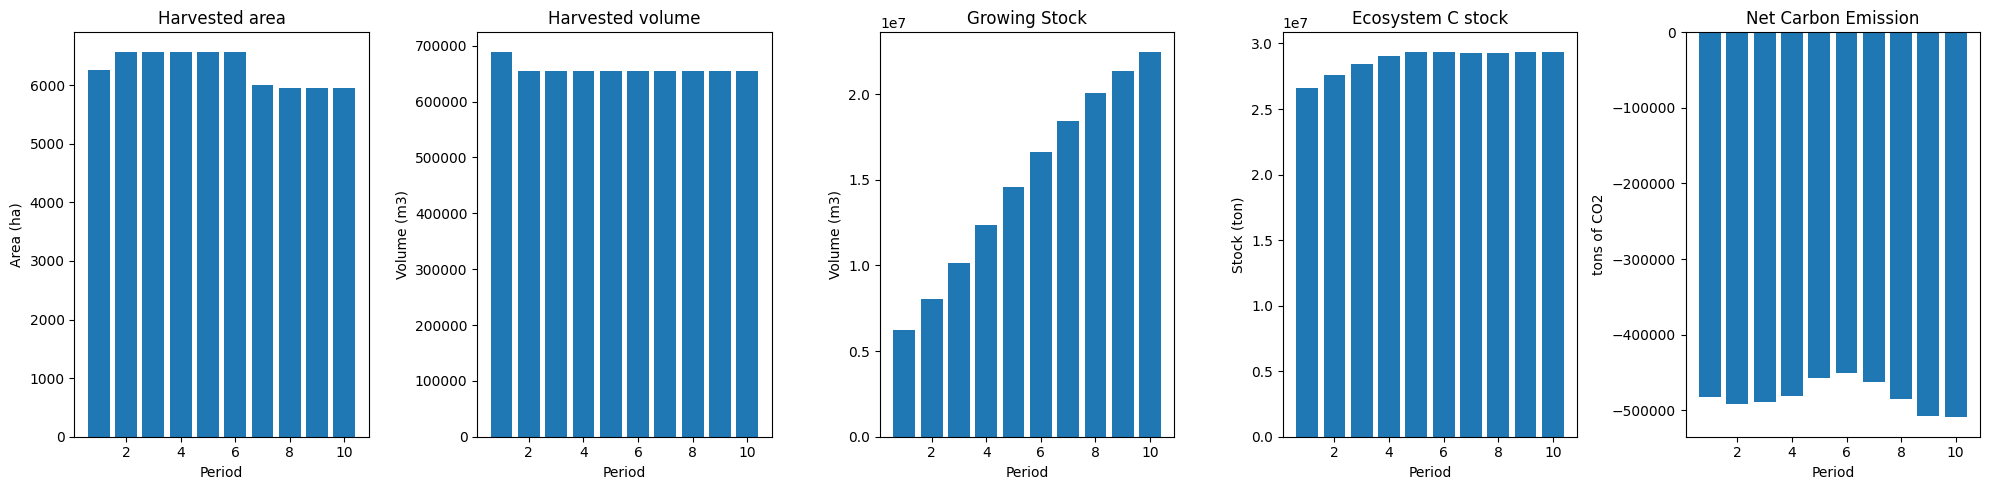

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_90%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6961
The economic indicator (the provincial government revenues) is:  237385
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


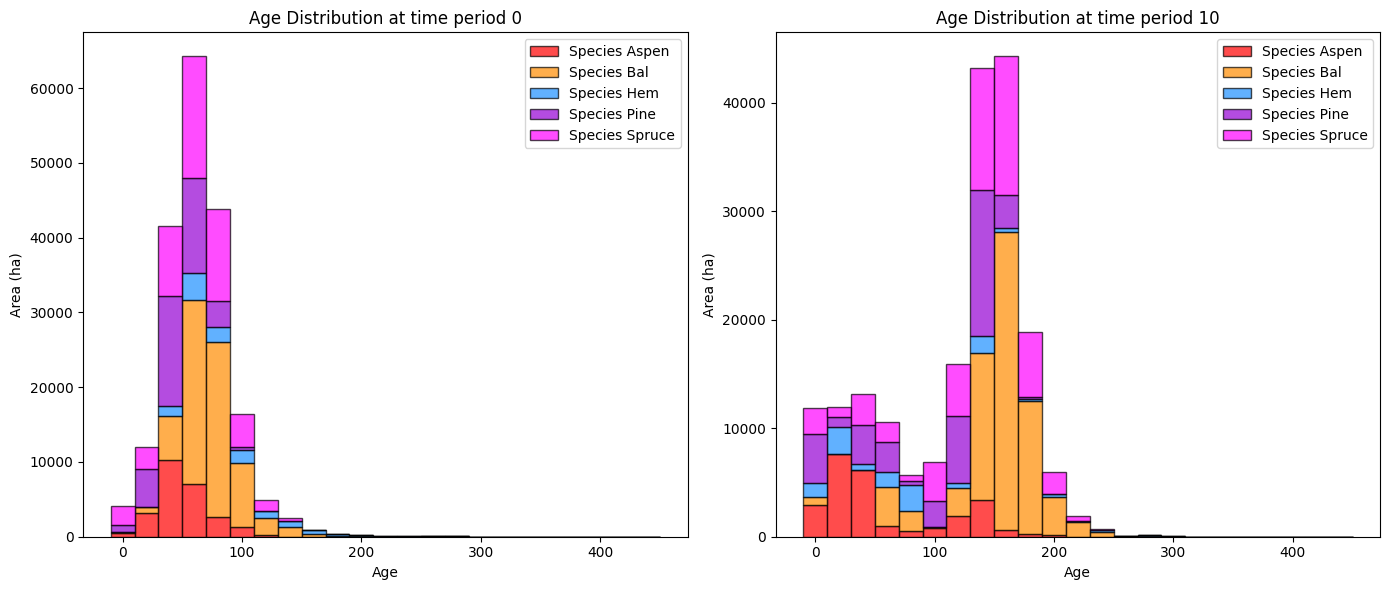

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_90%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5544.792177   5542.083643
Bal     278.565372  12247.617706  11969.052334
Aspen   273.490478   2448.845177   2175.354699
Pine      0.000000   4005.922411   4005.922411
Hem     419.699331    705.040396    285.341065

Overall diversity has **increased** by 23977.75 hectares from time period 0 to time period 10.


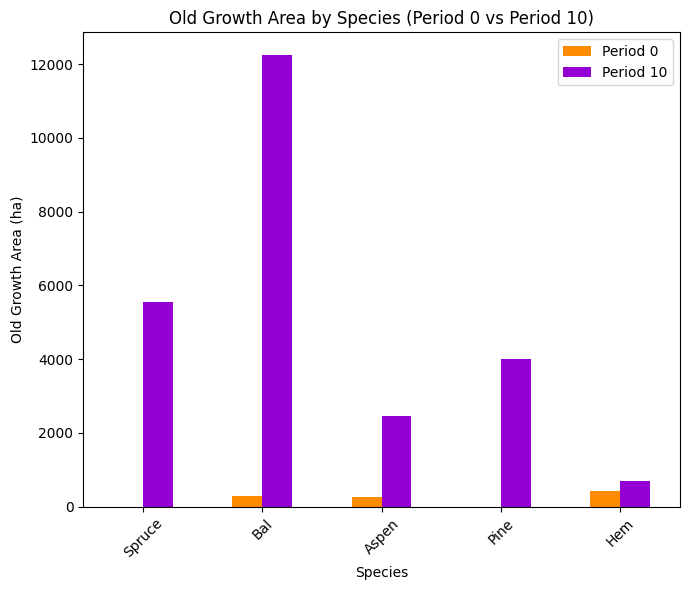

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_90%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8063

Diversity has **decreased** by 13.93% from time 0 to time 10.


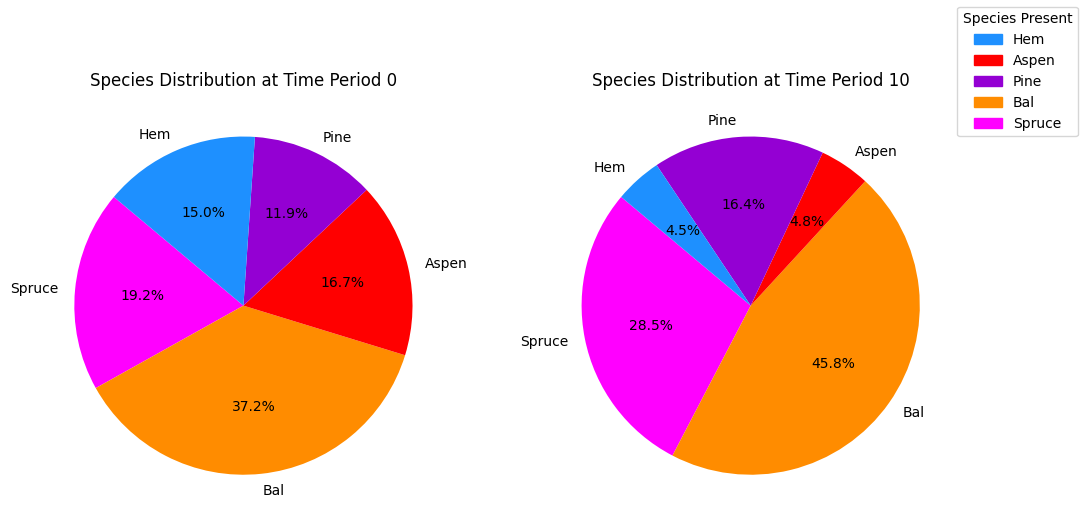

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_90%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x1b9e9885
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 4e+07]
Presolve removed 2037 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1912 rows, 34099 columns, 421112 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 6.876e+04
 Factor NZ  : 9.245e+04 (roughly 15 MB of memory)
 Fact

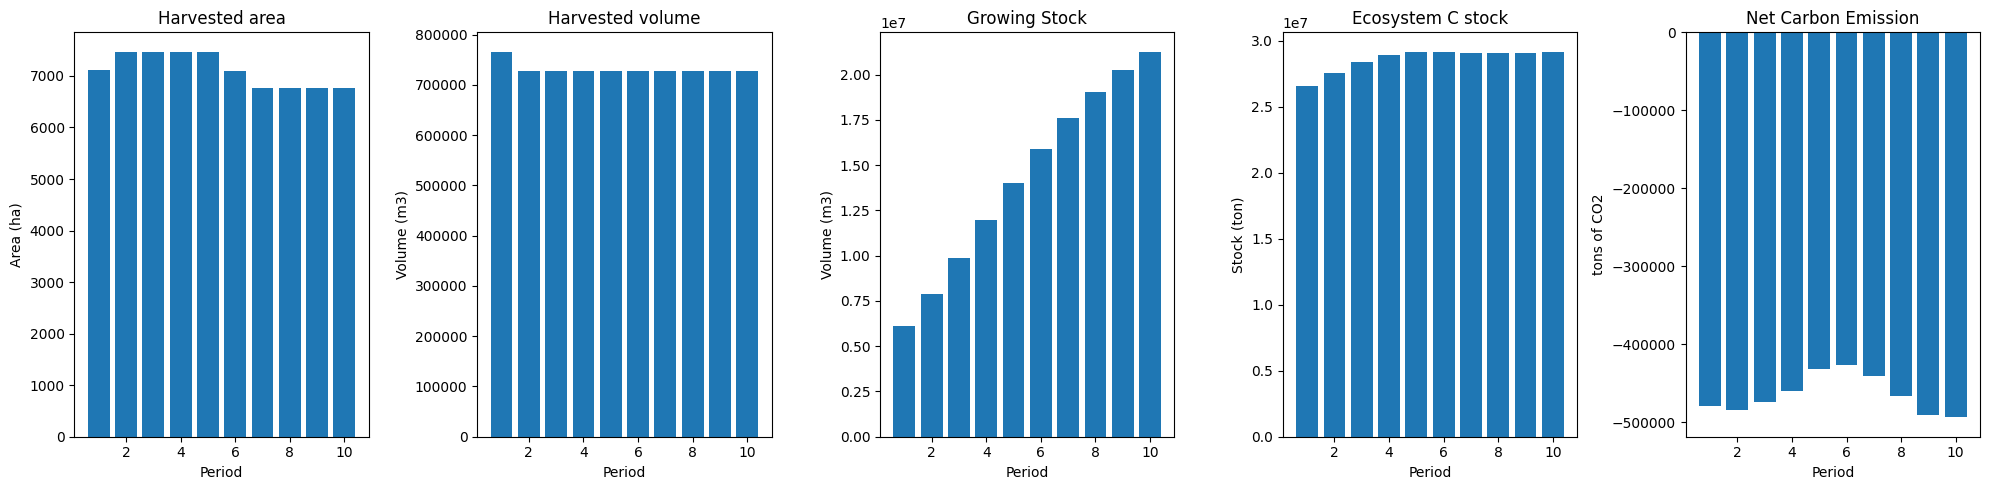

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


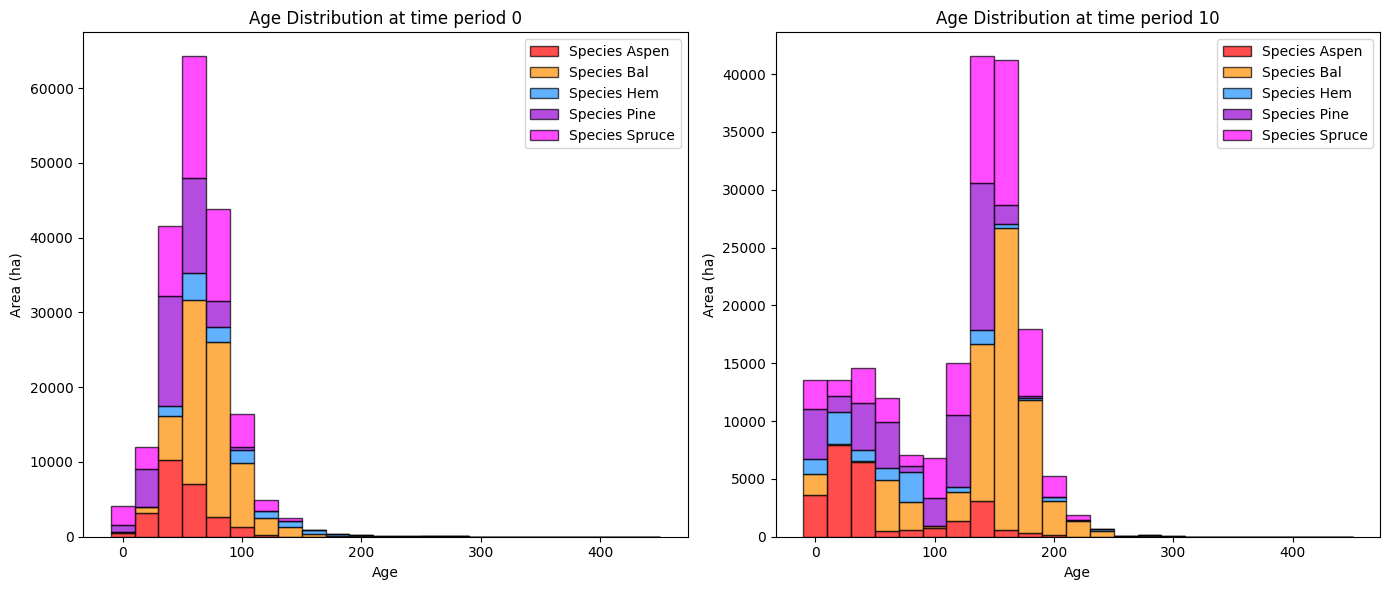

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Overall diversity has **increased** by 21663.54 hectares from time period 0 to time period 10.


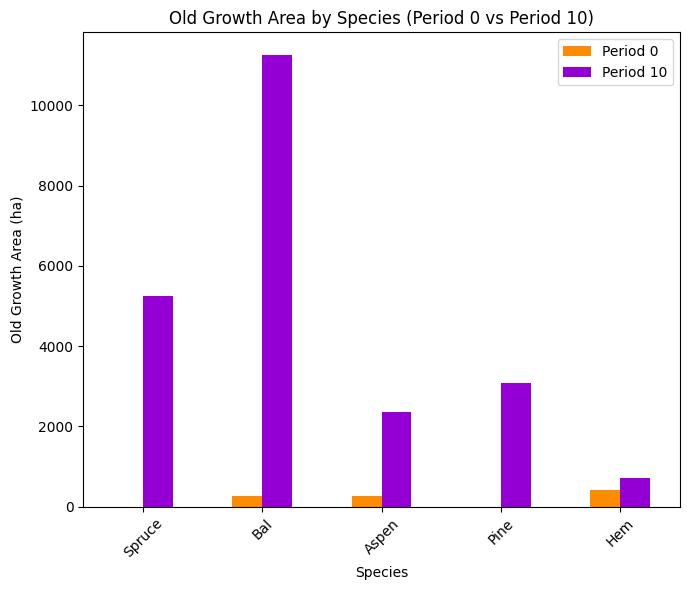

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


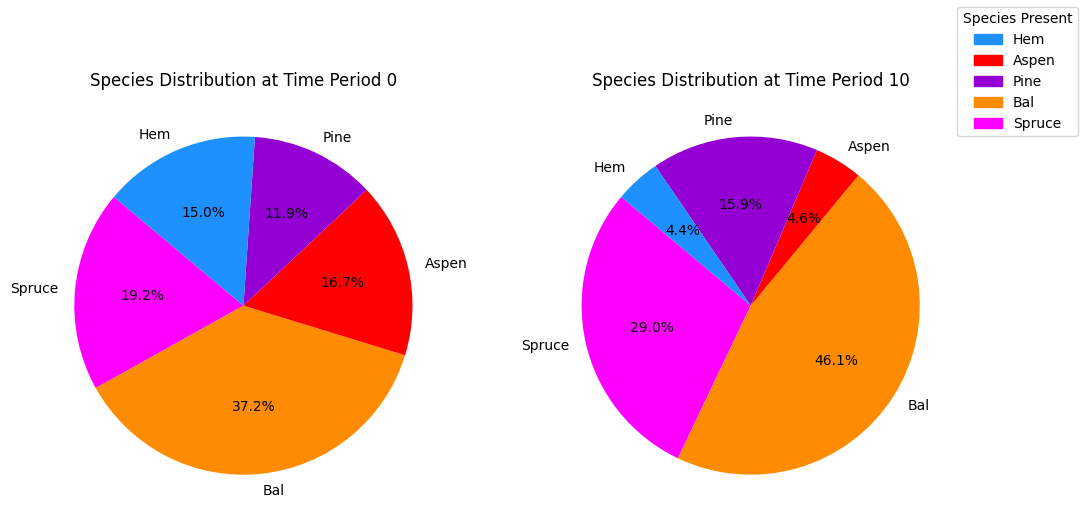

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


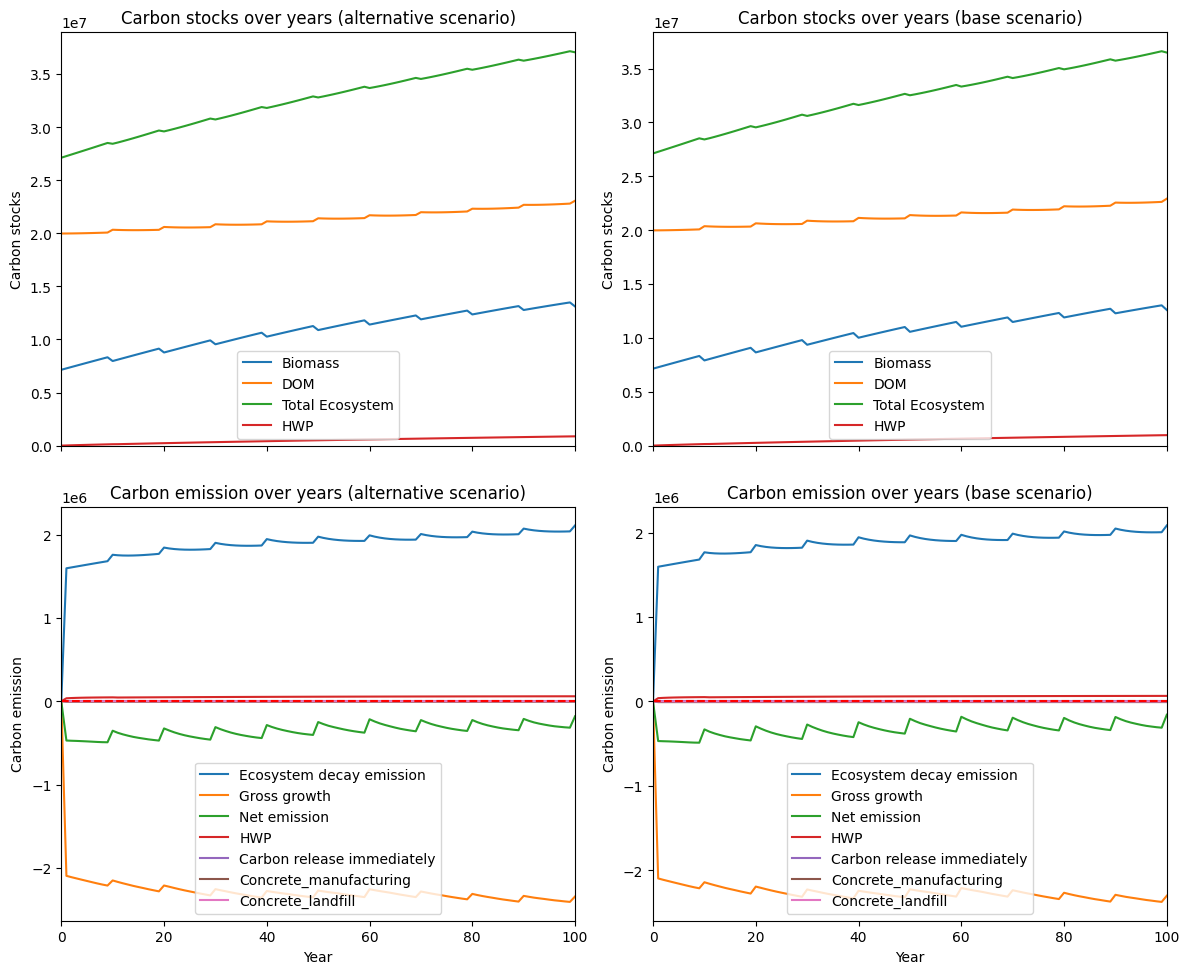

---------------------------------------------------------------------------------------
Net emission difference -327265.2186108821
Net emission base scenario -10451126.532641638
Net emission alternative scenario -10123861.314030755
dollar_per_ton is:  30.556256611827685
Comparison of Old Growth Areas (Alternative - Base)
          0          10  Difference
Spruce  0.0  301.982462  301.982462
Bal     0.0  994.623341  994.623341
Aspen   0.0   98.877601   98.877601
Pine    0.0  918.726051  918.726051
Hem     0.0    0.000000    0.000000

Overall, the old growth area has **increased** by 2314.21 hectares in the alternative scenario compared to the base scenario.


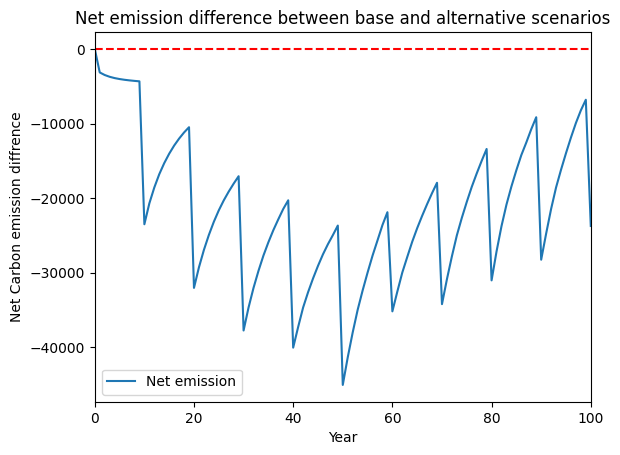

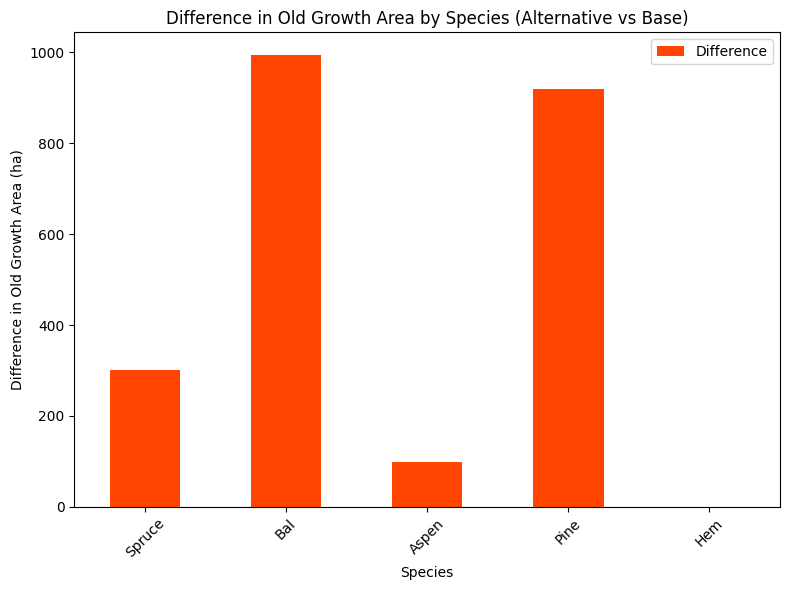

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


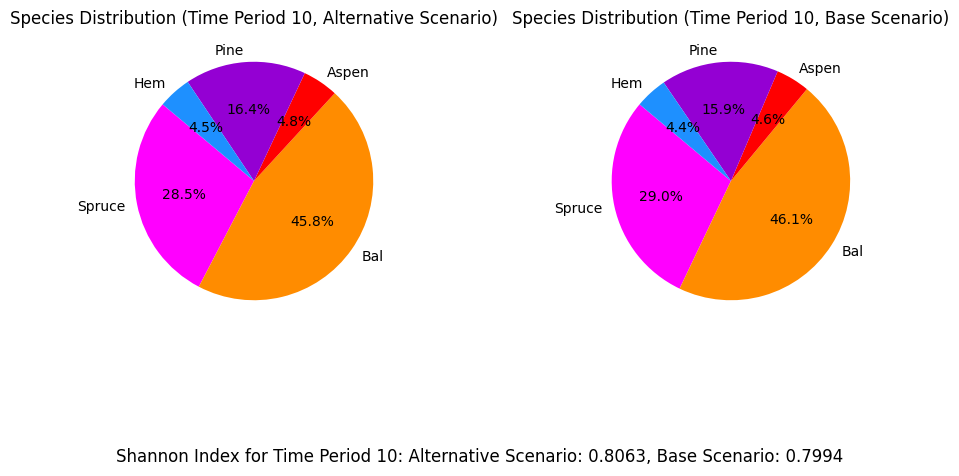

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_80%...
running the scenario for the Golden Bear mining site (80%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x54e44318
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.12s
Presolved: 1911 rows, 34100 

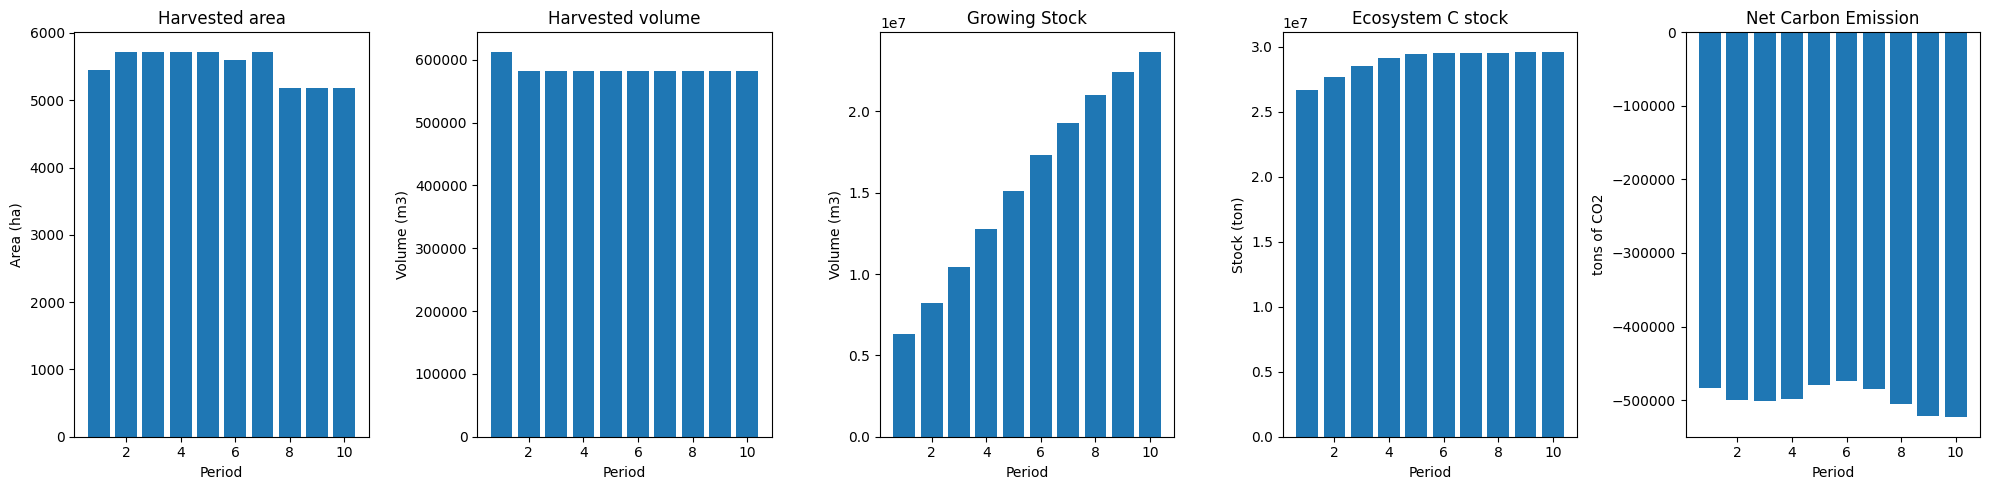

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_80%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6187
The economic indicator (the provincial government revenues) is:  211009
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


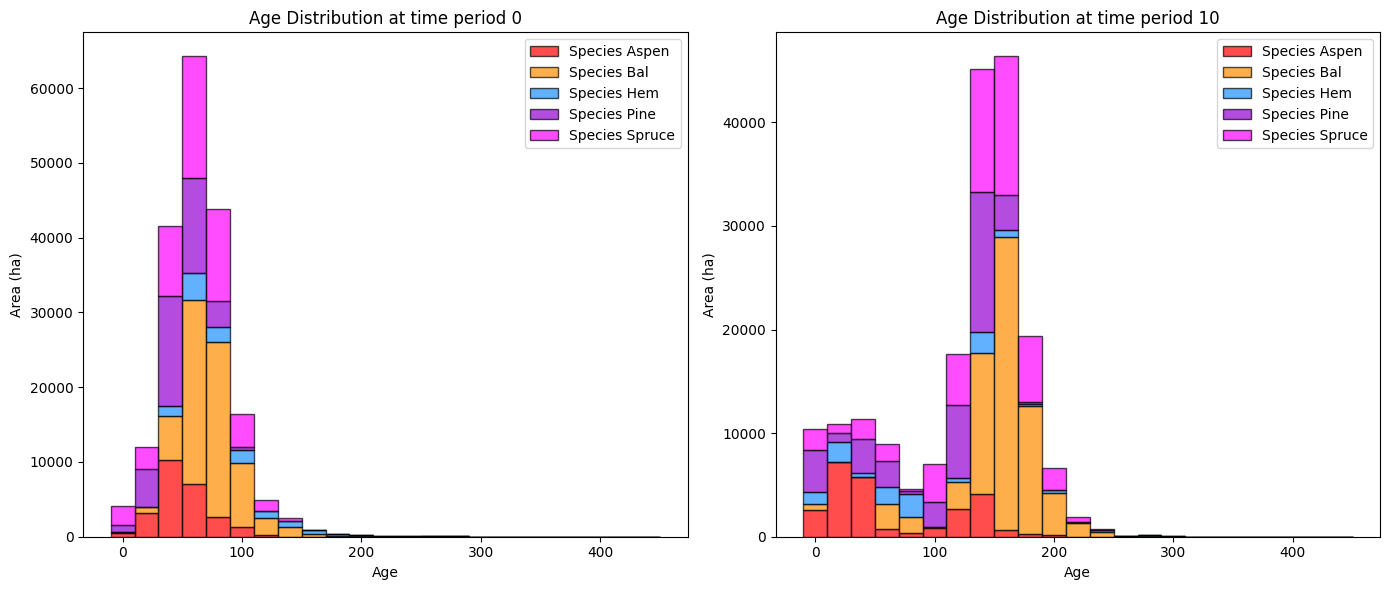

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_80%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5914.449954   5911.741421
Bal     278.565372  13018.483783  12739.918411
Aspen   273.490478   2809.975212   2536.484734
Pine      0.000000   4208.791544   4208.791544
Hem     419.699331    707.029353    287.330022

Overall diversity has **increased** by 25684.27 hectares from time period 0 to time period 10.


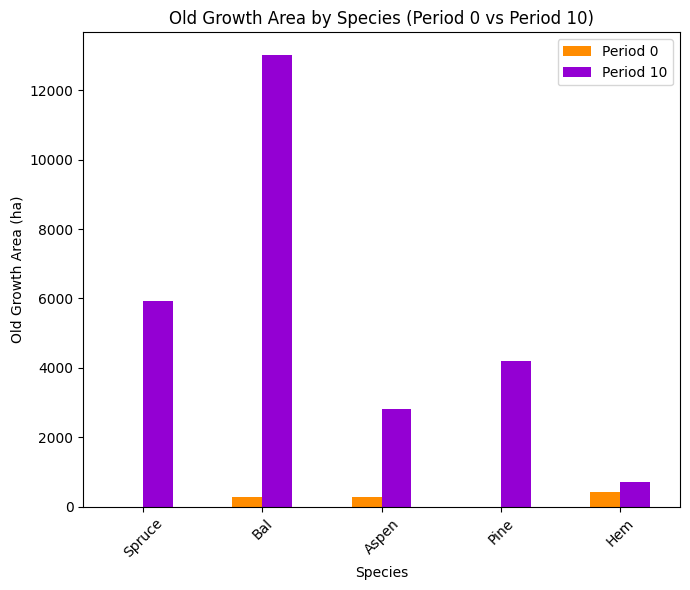

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_80%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8219

Diversity has **decreased** by 12.37% from time 0 to time 10.


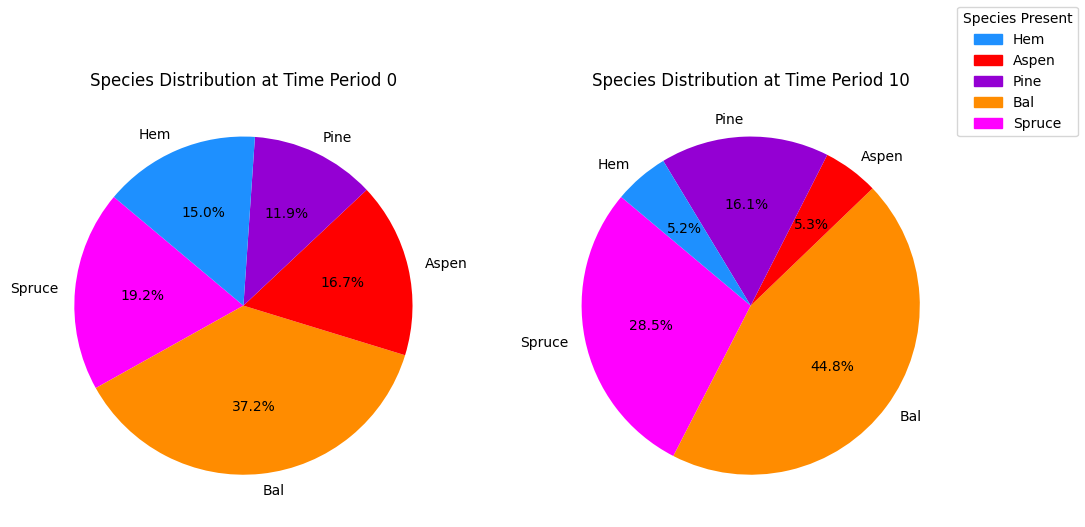

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_80%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x1b9e9885
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e-02, 2e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 4e+07]
Presolve removed 2037 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1912 rows, 34099 columns, 421112 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 6.876e+04
 Factor NZ  : 9.245e+04 (roughly 15 MB of memory)
 Fact

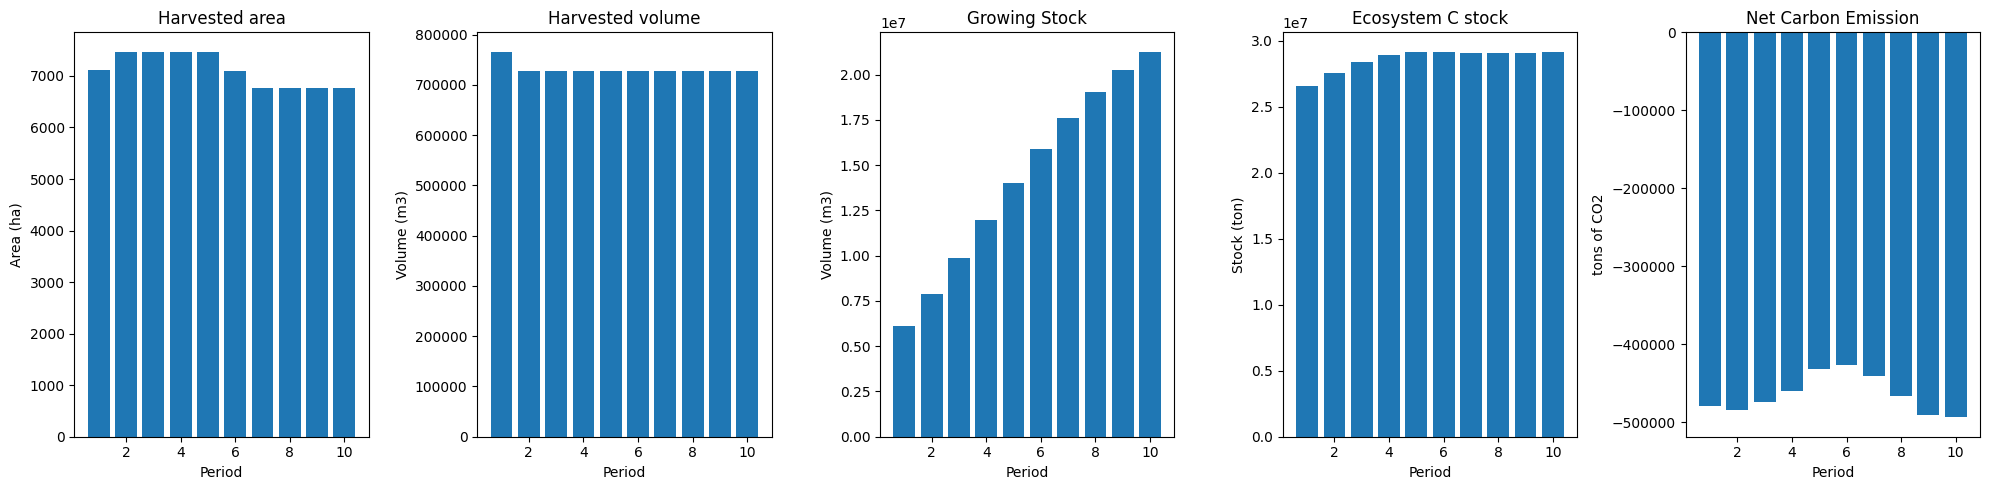

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------


In [ ]:
Start = time.time()
scenario_names = scenario_options.get(case_study, [])
for scenario_name in scenario_names:
    print(f"Running for {case_study}_{obj_mode}_{scenario_name}...")
    results_scenarios(fm, 
                      clt_percentage, 
                      credibility, 
                      budget_input, 
                      n_steps, 
                      max_harvest, 
                      scenario_name, 
                      displacement_effect, 
                      hwp_pool_effect_value, 
                      release_immediately_value, 
                      case_study, 
                      obj_mode,                   
                      pickle_output_base=False, 
                      pickle_output_alter=False)
print('It took', round((time.time() - Start) / 60, 1), "minutes to run all scenarios.")

In [ ]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")